# Companion Analysis — Cooling Cravers to the Carefree

**Behavioral archetypes of thermal preference from city-scale longitudinal smartwatch micro-surveys**

This notebook is the reproducible companion to the manuscript. It runs the full analysis end to end,
from the raw Cozie Singapore micro-surveys to every data figure in the paper, and documents each step
so the notebook can be read alongside the manuscript.

Every number quoted in the paper is produced here by executed code; the notebook is self-contained and
deterministic. It loads data **directly from the two public source repositories** and writes the
regenerated figures and tables into this repository's `analysis/` folder.

### Data sources

| Dataset | Repository | Role |
|---------|-----------|------|
| Survey-level micro-surveys (9,962 × 431) | `cozie-singapore-journal` | Thermal preference, outdoor heat index, space type, and wearable-physiology aggregates used to build and scrutinize the archetypes. |
| Onboarding survey | `make-yourself-comfortable-jitai-journal-paper` | TIPI personality, SWLS, HSP sensory sensitivity, demographics, and acclimatization used to test whether stable traits predict archetype membership. |

The two source repositories are expected to sit **next to this one** under a common parent directory.

### Manuscript figure map

| Manuscript | Notebook tag | What it shows |
|-----------|--------------|---------------|
| Figure 3 | `00_A2` | Survey composition and thermal preference by space type |
| Figure 4 | `00_C1` | Empirical-Bayes feature construction |
| Figure 5 | `01_S1` | Four-archetype overview schematic |
| Figure 6 | `00_D2` | Clustering diagnostics (PCA + silhouette) |
| Figure 7 | `00_D3` | Standardized archetype signatures |
| Figure 8 | `01_A3` | Prefer-cooler responses across control contexts |
| Figure 9 | `01_B1` | Over-cooling anatomy |
| Figure 10 | `01_C3` | Heat dose-response across control supergroups |
| Figure 11 | `01_C2` | Heat coupling by archetype |
| Figure 12 | `01_D1` | Outdoor exposure and provoked comfort |
| Figure 13 | `01_E1` | Independent survey behaviors |
| Figure 14 | `01_E3` | Wearable physiology |
| Figure 15 | `02_B1` | Onboarding measures |

Figures 1 (influence schematic) and 2 (Cozie interface) in the manuscript are illustrations with no
data dependency and are not produced here. Supporting diagnostics below are labeled as such; they
justify choices discussed in the paper but are not themselves manuscript figures.

> Data are participant-nested. All results are read **descriptively / associationally**, not causally;
> effect sizes are emphasized over p-values.

## Setup — Imports, Conventions, and Data Load

We fix the figure style used throughout the manuscript (Times New Roman serif, bold titles), locate the
two sibling data repositories robustly (independent of the kernel's working directory), and load the
public survey dataset. We keep rows with a valid thermal preference and a non-null outdoor heat index,
then derive the per-survey indicators used everywhere below: `cooler`, `warmer`, `nochange`, an
`outdoor` flag, and a global median heat-index split (`hot`). The archetype palette, ordering, and
mnemonics (the "four C's") are fixed here so the whole notebook stays internally consistent.

In [30]:
# ============================================================================
# SETUP & DATA LOAD  (self-contained; public source datasets)
# ============================================================================
import os
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from pathlib import Path
from scipy import stats
from scipy.special import betaln
from scipy.optimize import minimize
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples, adjusted_rand_score

# --- manuscript figure style: Times New Roman serif, slightly larger fonts, bold titles ---
plt.rcParams.update({'font.size': 12.5, 'axes.titlesize': 13, 'axes.labelsize': 12.5,
                     'axes.titleweight': 'bold', 'figure.dpi': 110,
                     'font.family': 'serif',
                     'font.serif': ['Times New Roman', 'Nimbus Roman No9 L',
                                    'Liberation Serif', 'DejaVu Serif'],
                     'mathtext.fontset': 'stix'})
%config InlineBackend.figure_format = 'retina'

# --- locate the sibling data repositories (robust to the kernel working directory) ---
def _find_base():
    here = Path.cwd().resolve()
    for cand in [here, *here.parents]:
        if ((cand / 'cozie-singapore-journal').is_dir()
                and (cand / 'make-yourself-comfortable-jitai-journal-paper').is_dir()):
            return cand
    raise FileNotFoundError(
        "Could not find the sibling repositories 'cozie-singapore-journal' and "
        "'make-yourself-comfortable-jitai-journal-paper'. Place them next to this repository.")

BASE   = _find_base()
DATA   = BASE / 'cozie-singapore-journal' / 'data' / 'cozie_singapore_survey_dataset.parquet.gzip'
OB     = BASE / 'make-yourself-comfortable-jitai-journal-paper' / '1_data' / '1_onboarding_survey_all_participants.csv'
REPO   = BASE / 'cooling-cravers-to-carefree-journal-paper'
FIGDIR = REPO / 'analysis' / 'figures'
OUTDIR = REPO / 'analysis' / 'outputs'
FIGDIR.mkdir(parents=True, exist_ok=True)
OUTDIR.mkdir(parents=True, exist_ok=True)

# --- shared archetype identity (descriptive name + one-word mnemonic, the "four C's") ---
PREFS = ['Cooler', 'No change', 'Warmer']
HOME  = 'Indoor - Home'
ORDER4 = ['Constant Cool-Seekers', 'Often Over-Cooled', 'Normatively Responsive', 'Heat-Unbothered']
MNEMONIC = {'Constant Cool-Seekers': 'Craver', 'Often Over-Cooled': 'Captive',
            'Normatively Responsive': 'Conventional', 'Heat-Unbothered': 'Carefree'}
APAL = {'Constant Cool-Seekers': '#e34a33', 'Often Over-Cooled': '#2c7fb8',
        'Normatively Responsive': '#f0a93b', 'Heat-Unbothered': '#7fbf7b'}
ARCH_LABEL = {a: f'{MNEMONIC[a]} — {a}' for a in ORDER4}   # e.g. "Craver — Constant Cool-Seekers"

# --- load & prepare the public survey dataset ---
df = pd.read_parquet(DATA, engine='fastparquet')
valid = df['q_thermal_preference'].isin(PREFS) & df['heat_index_mean_1h'].notna()
v = df[valid].copy()
v['cooler']   = (v['q_thermal_preference'] == 'Cooler').astype(int)
v['warmer']   = (v['q_thermal_preference'] == 'Warmer').astype(int)
v['nochange'] = (v['q_thermal_preference'] == 'No change').astype(int)
HImed = v['heat_index_mean_1h'].median()
v['hot']     = (v['heat_index_mean_1h'] >= HImed).astype(int)
v['outdoor'] = (v['q_location'] == 'Outdoor').astype(int)     # ambient / not air-conditioned

_serif = next((f for f in ['Times New Roman', 'Nimbus Roman No9 L', 'Liberation Serif']
               if f in {x.name for x in fm.fontManager.ttflist}), 'DejaVu Serif (fallback)')
print(f"Data base directory        : {BASE}")
print(f"Serif font in use          : {_serif}")
print(f"Raw survey rows            : {len(df):,} × {df.shape[1]}")
print(f"Valid (pref + heat) rows   : {len(v):,}  | participants: {v['id_participant'].nunique()}")
print(f"Global median heat index   : {HImed:.1f} °C")
print(f"Overall P(Cooler)/P(Warmer): {v['cooler'].mean():.3f} / {v['warmer'].mean():.3f}")

Data base directory        : /Users/cmiller/Documents/GitHub
Serif font in use          : Times New Roman
Raw survey rows            : 9,962 × 431
Valid (pref + heat) rows   : 9,520  | participants: 106
Global median heat index   : 34.1 °C
Overall P(Cooler)/P(Warmer): 0.396 / 0.060


## Part 1 — Cohort Characterization

We first characterize the survey pool that the archetype features are built from. The manuscript
**Figure 3** (`00_A2`) shows the overall thermal-preference mix, the space-type mix, and how the
preference composition shifts by space type. Two supporting diagnostics — the number of surveys per
participant and the outdoor heat-index distribution — motivate the coverage screen and the
median heat split; they are not manuscript figures.

**Supporting diagnostic — surveys per participant.** Motivates the ≥15-survey coverage floor used below.

Surveys per participant — min 17, median 96, max 156, mean 89.8


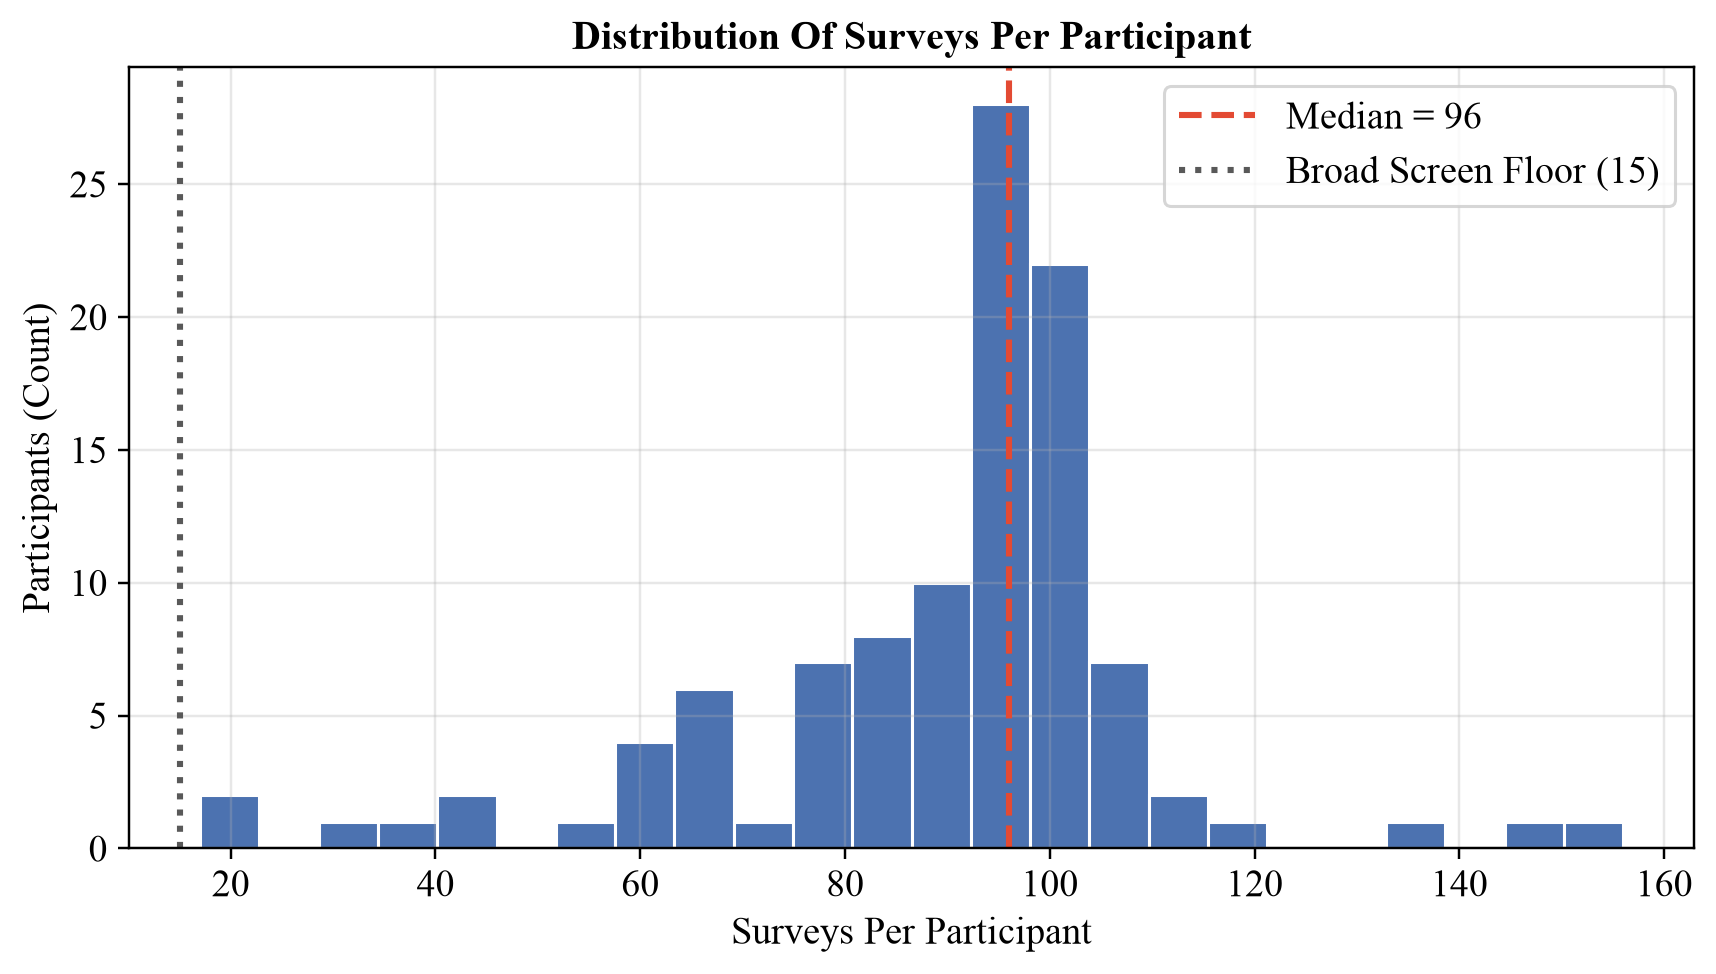

In [31]:
# --- Diagnostic Figure A1 · Surveys-Per-Participant Distribution (not exported) ---
spp = v.groupby('id_participant').size()
print(f"Surveys per participant — min {spp.min()}, median {spp.median():.0f}, "
      f"max {spp.max()}, mean {spp.mean():.1f}")

fig, ax = plt.subplots(figsize=(8, 4.6))
ax.hist(spp.values, bins=24, color='#4c72b0', edgecolor='white')
ax.axvline(spp.median(), color='#e34a33', ls='--', lw=2,
           label=f'Median = {spp.median():.0f}')
ax.axvline(15, color='0.35', ls=':', lw=2, label='Broad Screen Floor (15)')
ax.set_xlabel('Surveys Per Participant'); ax.set_ylabel('Participants (Count)')
ax.set_title('Distribution Of Surveys Per Participant')
ax.legend(frameon=True); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Manuscript Figure 3 (`00_A2`) — survey composition and thermal preference by space type.**

Thermal-preference mix (%):
q_thermal_preference
Cooler       39.6
No change    54.3
Warmer        6.0

Space-type mix (%):
q_location
Indoor - Home      45.1
Indoor - Office    18.1
Indoor - Other     13.5
Outdoor            10.8
Transportation      6.4
Indoor - Class      6.1

P(preference | space type), %:
q_thermal_preference  Cooler  No change  Warmer
q_location                                     
Indoor - Home           43.1       52.8     4.1
Indoor - Office         25.4       65.2     9.4
Indoor - Other          34.5       57.2     8.2
Outdoor                 53.4       41.1     5.4
Transportation          41.2       54.0     4.8
Indoor - Class          41.2       50.8     8.0


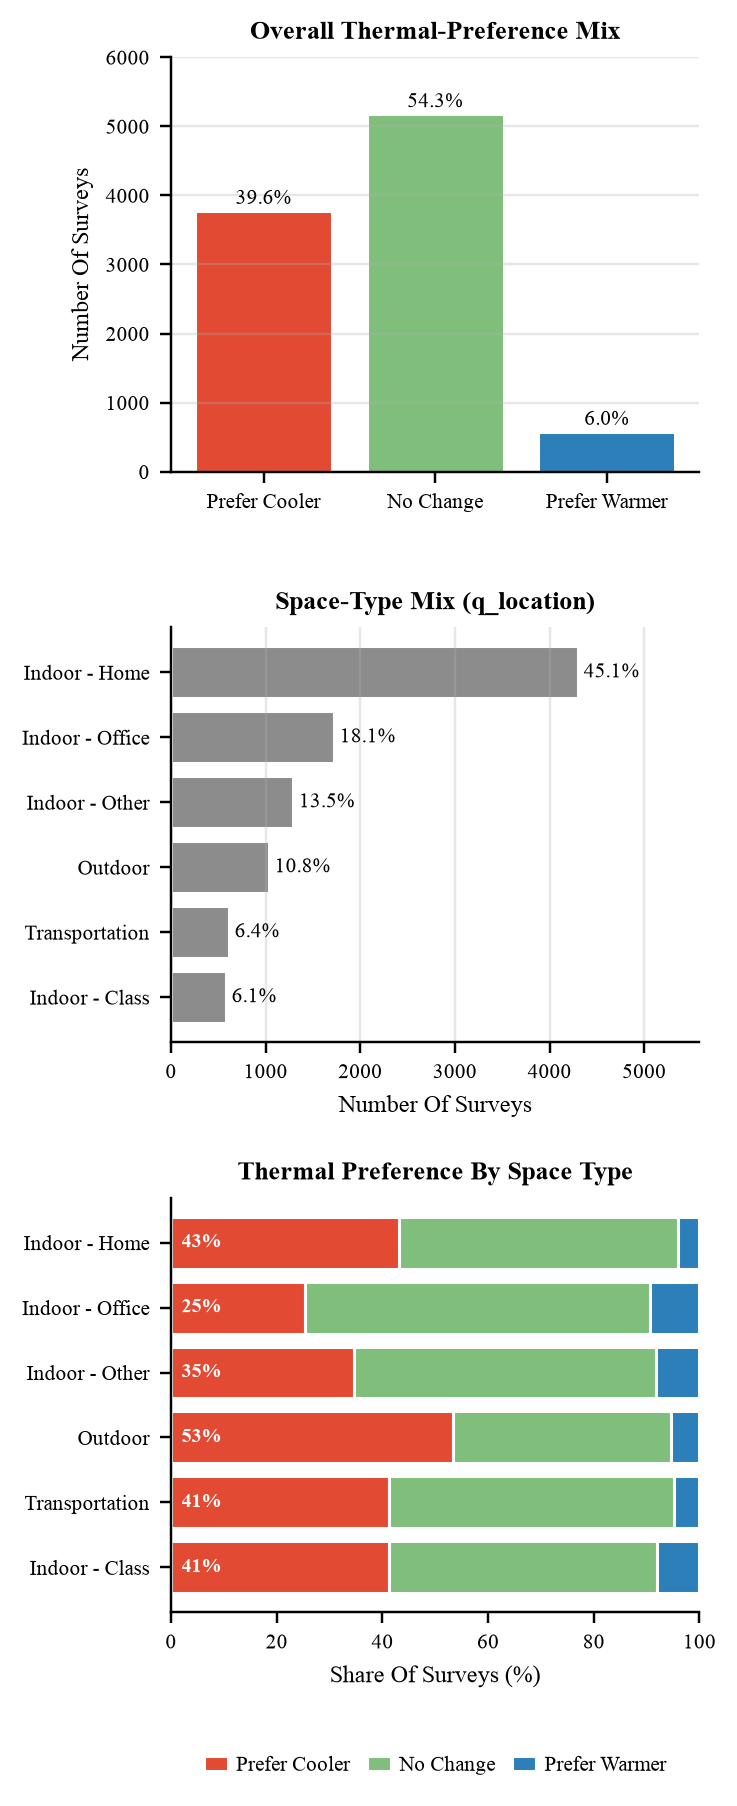

In [32]:
# --- Figure 00_A2 · Thermal-Preference Mix + Space-Type Mix + Preference By Space ---
# Single-column, 3-panel vertical stack (ground-truth layout). Explicit small fonts
# (the global journal rcParams are too large at column width). Font sizes, spines
# and legend placement matched to the ground-truth manuscript figure.
import os
def r0(x): return int(np.floor(x + 0.5))          # round half up (match ground truth)
PREF_LABEL = {'Cooler': 'Prefer Cooler', 'No change': 'No Change', 'Warmer': 'Prefer Warmer'}
pcolors    = {'Cooler': '#e34a33', 'No change': '#7fbf7b', 'Warmer': '#2c7fb8'}
TS, LS, TK, WL = 8.5, 8, 7, 6.5                    # title / label / tick / white in-bar font sizes

pref_mix = v['q_thermal_preference'].value_counts().reindex(PREFS)
pref_pct = 100 * pref_mix / pref_mix.sum()
loc_mix  = v['q_location'].value_counts()
loc_pct  = 100 * loc_mix / loc_mix.sum()
loc_order = loc_mix.index.tolist()
ct = (pd.crosstab(v['q_location'], v['q_thermal_preference'], normalize='index')[PREFS]
      .reindex(loc_order) * 100)
print("Thermal-preference mix (%):\n" + pref_pct.round(1).to_string())
print("\nSpace-type mix (%):\n" + loc_pct.round(1).to_string())
print("\nP(preference | space type), %:\n" + ct.round(1).to_string())

fig, axes = plt.subplots(3, 1, figsize=(3.6, 8.4))

# (1) Overall preference mix — vertical bars (counts), % annotated (regular weight, matching GT)
ax = axes[0]
ax.bar([PREF_LABEL[p] for p in PREFS], pref_mix.values,
       color=[pcolors[p] for p in PREFS], edgecolor='white')
for i, (cnt, pct) in enumerate(zip(pref_mix.values, pref_pct.values)):
    ax.text(i, cnt + pref_mix.max() * 0.02, f'{pct:.1f}%', ha='center', fontsize=TK)
ax.set_ylabel('Number Of Surveys', fontsize=LS); ax.set_ylim(0, pref_mix.max() * 1.16)
ax.set_title('Overall Thermal-Preference Mix', fontsize=TS)
ax.tick_params(labelsize=TK); ax.grid(axis='y', alpha=0.3)

# (2) Space-type mix — horizontal gray bars (counts), largest on top, % annotated
ax = axes[1]
ypos = np.arange(len(loc_order))
ax.barh(ypos, loc_mix.reindex(loc_order).values, color='#8c8c8c', edgecolor='white')
ax.set_yticks(ypos); ax.set_yticklabels(loc_order); ax.invert_yaxis()
for y, loc in zip(ypos, loc_order):
    ax.text(loc_mix[loc] + loc_mix.max() * 0.015, y, f'{loc_pct[loc]:.1f}%', va='center', fontsize=TK)
ax.set_xlabel('Number Of Surveys', fontsize=LS); ax.set_xlim(0, loc_mix.max() * 1.30)
ax.set_title('Space-Type Mix (q_location)', fontsize=TS)
ax.tick_params(labelsize=TK); ax.grid(axis='x', alpha=0.3)

# (3) Preference by space — 100% stacked horizontal; Cooler share annotated in white (bold)
ax = axes[2]
left = np.zeros(len(loc_order))
for p in PREFS:
    ax.barh(ypos, ct[p].values, left=left, color=pcolors[p], edgecolor='white', label=PREF_LABEL[p])
    left = left + ct[p].values
ax.set_yticks(ypos); ax.set_yticklabels(loc_order); ax.invert_yaxis()
for y, loc in zip(ypos, loc_order):
    ax.text(2, y, f"{r0(ct.loc[loc, 'Cooler'])}%", va='center', color='white', fontweight='bold', fontsize=WL)
ax.set_xlabel('Share Of Surveys (%)', fontsize=LS); ax.set_xlim(0, 100)
ax.set_title('Thermal Preference By Space Type', fontsize=TS)
ax.tick_params(labelsize=TK)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.30), ncol=3, frameon=False, fontsize=7,
          handlelength=1.1, handletextpad=0.4, columnspacing=0.8)

# match ground truth: only left + bottom axis lines (drop top/right spines)
for ax in axes:
    ax.spines[['top', 'right']].set_visible(False)

fig.tight_layout()
os.makedirs(str(FIGDIR), exist_ok=True)
fig.savefig(f'{FIGDIR}/00_A2_preference_mix_and_by_space.pdf', bbox_inches='tight')
plt.show()

**Supporting diagnostic — outdoor heat-index distribution.** The global median (~34 °C) defines the `hot` split.

Heat index (all valid) — median 34.1 °C, IQR [31.2, 36.1]
Heat index (Outdoor)   — median 34.2 °C, IQR [31.3, 36.1]


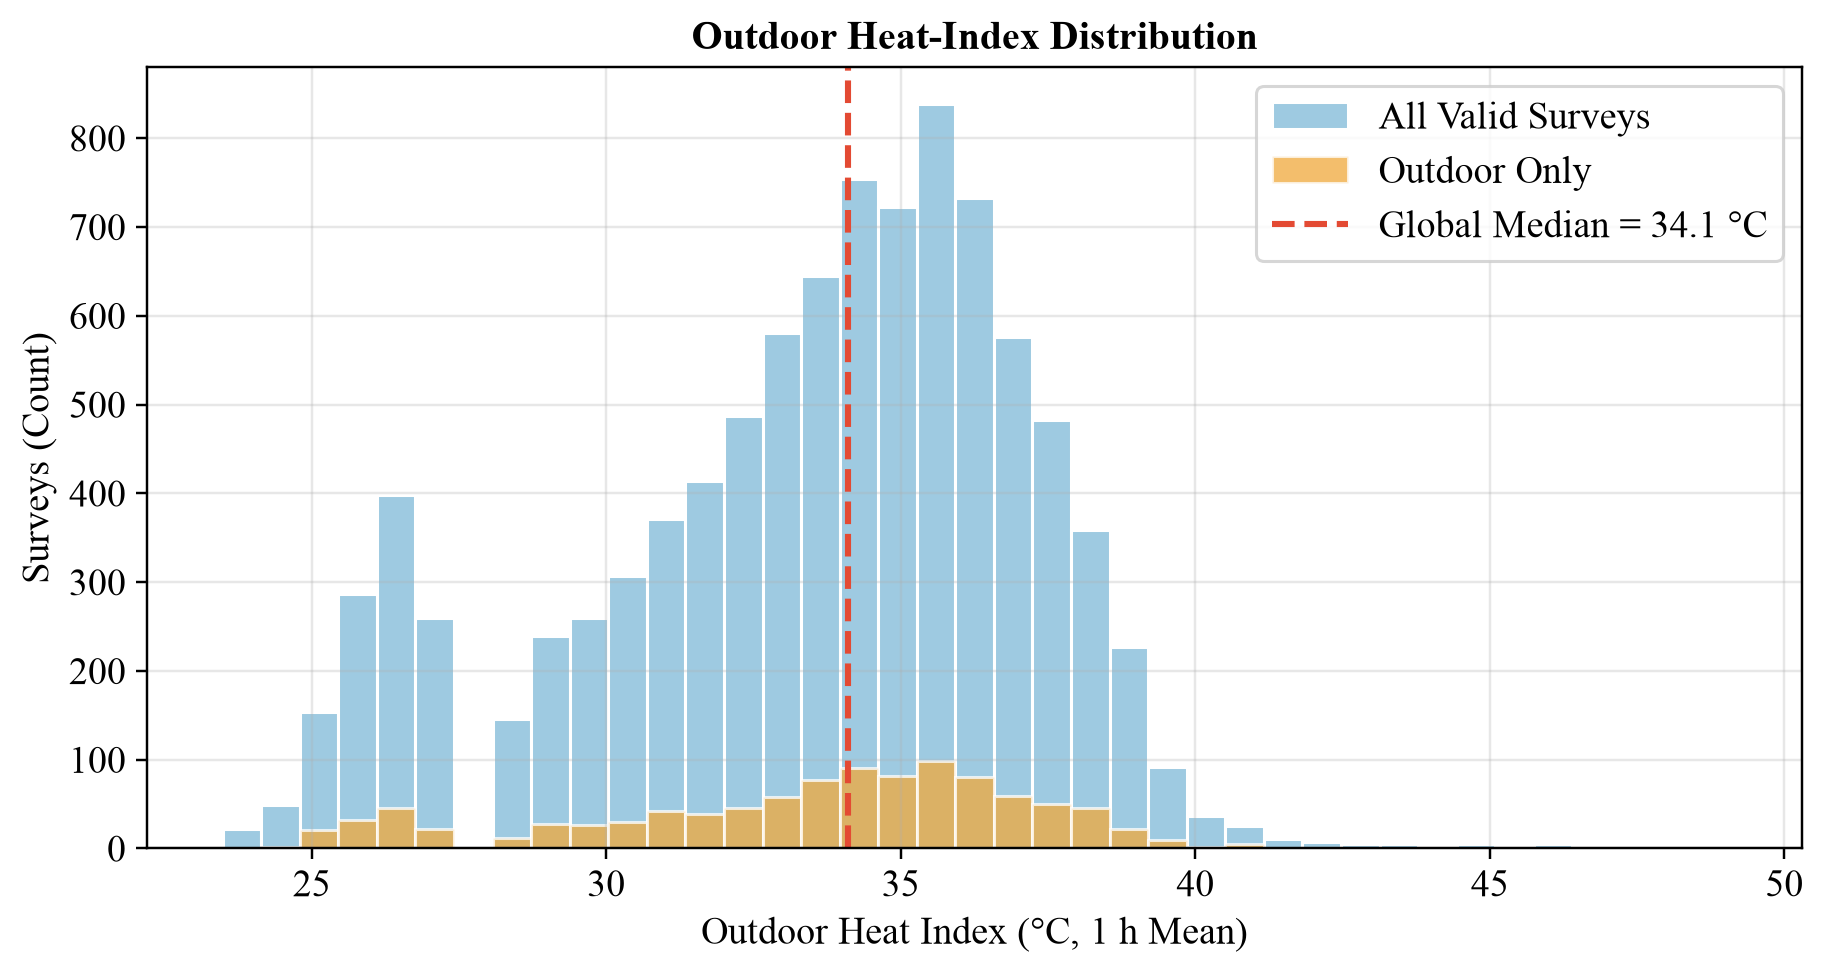

In [33]:
# --- Diagnostic Figure A3 · Outdoor Heat-Index Distribution (not exported) ---
hi_all = v['heat_index_mean_1h']
hi_out = v.loc[v['q_location'] == 'Outdoor', 'heat_index_mean_1h']
print(f"Heat index (all valid) — median {hi_all.median():.1f} °C, "
      f"IQR [{hi_all.quantile(.25):.1f}, {hi_all.quantile(.75):.1f}]")
print(f"Heat index (Outdoor)   — median {hi_out.median():.1f} °C, "
      f"IQR [{hi_out.quantile(.25):.1f}, {hi_out.quantile(.75):.1f}]")

fig, ax = plt.subplots(figsize=(8.5, 4.6))
bins = np.linspace(hi_all.min(), hi_all.max(), 40)
ax.hist(hi_all, bins=bins, color='#9ecae1', edgecolor='white', label='All Valid Surveys')
ax.hist(hi_out, bins=bins, color='#f0a93b', alpha=0.75, edgecolor='white', label='Outdoor Only')
ax.axvline(HImed, color='#e34a33', ls='--', lw=2, label=f'Global Median = {HImed:.1f} °C')
ax.set_xlabel('Outdoor Heat Index (°C, 1 h Mean)'); ax.set_ylabel('Surveys (Count)')
ax.set_title('Outdoor Heat-Index Distribution')
ax.legend(frameon=True); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Part 2 — Coverage: Why Broaden Beyond a Home-Only Screen

The archetype features could be estimated from home surveys only, but that discards nearly half the
cohort. Because the heat-tolerance behavior is portable across spaces, we instead estimate each
participant's features from **all** of their surveys and require only ≥15 responses with ≥5 hot and
≥5 cool. This retains **104 of 106** participants — the coverage figure quoted in the paper. The funnel
below is a supporting diagnostic.

In [34]:
# ============================================================================
# COVERAGE FUNNEL: home-only screen (00-03) vs broadened all-location screen
# ============================================================================
def qualify(frame, n_min, side_min=5):
    """Per-participant counts + qualification mask (n, hot-side, cool-side)."""
    gg = frame.groupby('id_participant')
    q = pd.DataFrame({'n': gg.size(), 'n_hot': gg['hot'].sum()})
    q['n_cool'] = q['n'] - q['n_hot']
    q['ok'] = (q['n'] >= n_min) & (q['n_hot'] >= side_min) & (q['n_cool'] >= side_min)
    return q

home = v[v['q_location'] == HOME].copy()
# home screen uses its own median split, matching the original pipeline exactly
home['hot'] = (home['heat_index_mean_1h'] >= home['heat_index_mean_1h'].median()).astype(int)

old = qualify(home, n_min=20, side_min=5)   # original home-only screen
new = qualify(v,    n_min=15, side_min=5)   # broadened, all-location screen

funnel = pd.DataFrame({
    'Stage': ['All Participants', 'Have ≥1 Valid Home Survey',
              'Old Screen: ≥20 Home, ≥5 Hot, ≥5 Cool',
              'New Screen: ≥15 Any-Loc, ≥5 Hot, ≥5 Cool'],
    'Participants': [df['id_participant'].nunique(), home['id_participant'].nunique(),
                     int(old['ok'].sum()), int(new['ok'].sum())],
})
funnel['% Of Cohort'] = (100 * funnel['Participants'] / df['id_participant'].nunique()).round(1)
print(funnel.to_string(index=False))
print(f"\nDropped by NEW screen: {sorted(set(new.index[~new['ok']]))}")

                                   Stage  Participants  % Of Cohort
                        All Participants           106        100.0
               Have ≥1 Valid Home Survey           106        100.0
   Old Screen: ≥20 Home, ≥5 Hot, ≥5 Cool            60         56.6
New Screen: ≥15 Any-Loc, ≥5 Hot, ≥5 Cool           104         98.1

Dropped by NEW screen: ['orenth37', 'orenth42']


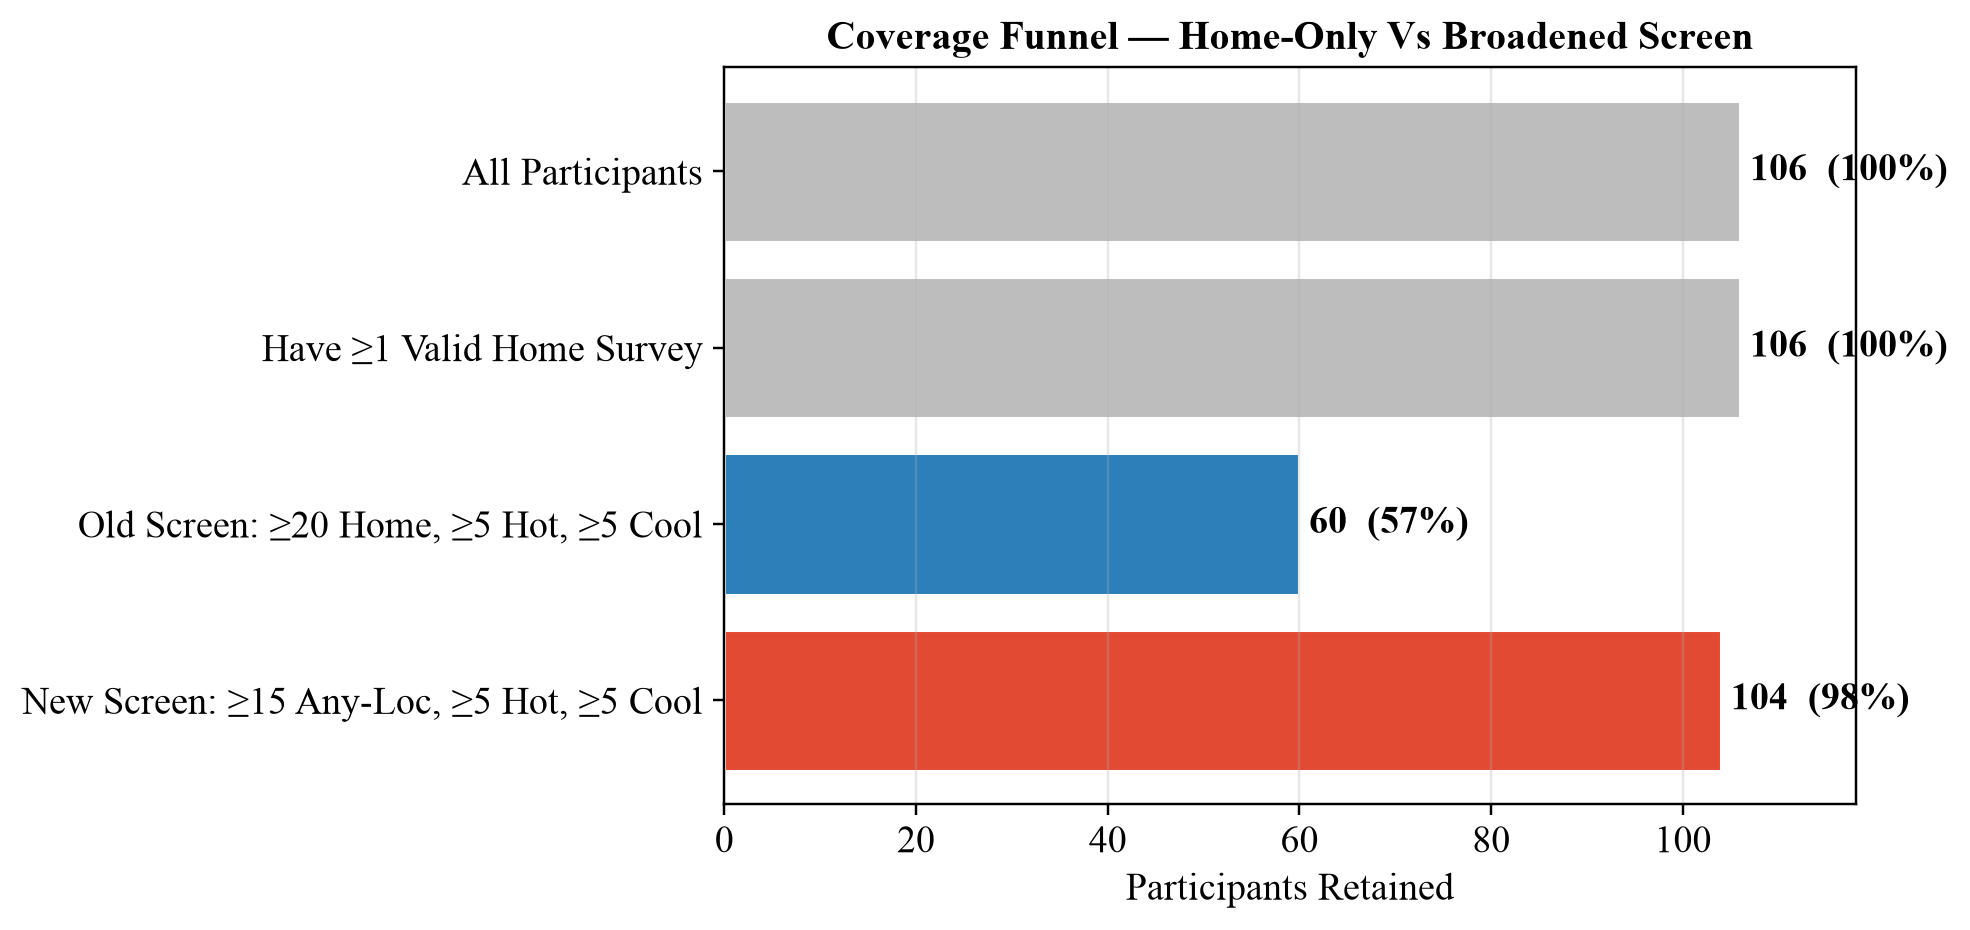

In [35]:
# --- Diagnostic Figure B1 · Coverage Funnel (not exported) ------------------
fig, ax = plt.subplots(figsize=(9, 4.4))
cols = ['#bdbdbd', '#bdbdbd', '#2c7fb8', '#e34a33']
bars = ax.barh(funnel['Stage'][::-1], funnel['Participants'][::-1],
               color=cols[::-1], edgecolor='white')
for i, (n, p) in enumerate(zip(funnel['Participants'][::-1], funnel['% Of Cohort'][::-1])):
    ax.text(n + 1, i, f'{n}  ({p:.0f}%)', va='center', fontweight='bold')
ax.set_xlabel('Participants Retained'); ax.set_xlim(0, 118)
ax.set_title('Coverage Funnel — Home-Only Vs Broadened Screen')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout(); plt.show()

## Part 3 — Person-Level Features and Empirical-Bayes Shrinkage

Each participant is summarized by three behavioral features on the all-location survey pool:

- **`cooler_rate`** — propensity to prefer cooler, P(Cooler): the core cooling-demand signal.
- **`warmer_rate`** — propensity to prefer warmer / feel too cold, P(Warmer): the over-cooling signal.
- **`heat_sensitivity`** — heat coupling, P(Cooler | hot) − P(Cooler | cool): how much cooling demand
  tracks outdoor heat.

Because "warmer" is rare (~6% overall) and per-person counts vary widely, raw rates are noisy for
low-count participants. We stabilize `cooler_rate` and `warmer_rate` with **empirical-Bayes
shrinkage**: a Beta(a, b) prior is fitted by maximizing the Beta-Binomial marginal likelihood across
all participants, then each participant's rate is shrunk toward that prior in proportion to how little
data they contributed. `heat_sensitivity` is a within-person difference (computed only with ≥5 hot and
≥5 cool surveys) and is left unshrunk. Manuscript **Figure 4** (`00_C1`) shows the fitted priors and
the raw-versus-shrunk distributions.

In [36]:
# ============================================================================
# PERSON-LEVEL FEATURES + empirical-Bayes shrinkage of the response rates
# ============================================================================
def eb_beta_prior(x, n):
    """Fit a Beta(a,b) prior by max marginal (Beta-Binomial) likelihood."""
    x, n = np.asarray(x, float), np.asarray(n, float)
    m = x.sum() / n.sum()
    nll = lambda th: -(betaln(x + np.exp(th[0]), n - x + np.exp(th[1])) - betaln(*np.exp(th))).sum()
    a, b = np.exp(minimize(nll, [np.log(m * 20), np.log((1 - m) * 20)], method='Nelder-Mead').x)
    return a, b
shrink = lambda x, n, a, b: (np.asarray(x, float) + a) / (np.asarray(n, float) + a + b)

g = v.groupby('id_participant')
feat = pd.DataFrame({'n': g.size(), 'n_hot': g['hot'].sum(),
                     'cooler_x': g['cooler'].sum(), 'warmer_x': g['warmer'].sum(),
                     'cooler_raw': g['cooler'].mean(), 'warmer_raw': g['warmer'].mean()})
feat['n_cool'] = feat['n'] - feat['n_hot']
feat['nochange_raw'] = 1 - feat['cooler_raw'] - feat['warmer_raw']

def heat_sens(s):
    h, c = s[s['hot'] == 1], s[s['hot'] == 0]
    return h['cooler'].mean() - c['cooler'].mean() if len(h) >= 5 and len(c) >= 5 else np.nan
feat['heat_sensitivity'] = g.apply(heat_sens, include_groups=False)

a_c, b_c = eb_beta_prior(feat['cooler_x'], feat['n'])
a_w, b_w = eb_beta_prior(feat['warmer_x'], feat['n'])
feat['cooler_rate'] = shrink(feat['cooler_x'], feat['n'], a_c, b_c)
feat['warmer_rate'] = shrink(feat['warmer_x'], feat['n'], a_w, b_w)

ok = (feat['n'] >= 15) & (feat['n_hot'] >= 5) & (feat['n_cool'] >= 5)
qual = feat[ok].copy()

print(f"Cooler prior  Beta(a={a_c:.2f}, b={b_c:.2f}) -> strength {a_c+b_c:.1f} surveys, mean {a_c/(a_c+b_c):.3f}")
print(f"Warmer prior  Beta(a={a_w:.2f}, b={b_w:.2f}) -> strength {a_w+b_w:.1f} surveys, mean {a_w/(a_w+b_w):.3f}")
print(f"\nQualifying participants: {len(qual)}  (heat_sensitivity available: {qual['heat_sensitivity'].notna().sum()})")
print(qual[['n', 'cooler_raw', 'cooler_rate', 'warmer_raw', 'warmer_rate', 'heat_sensitivity']].describe().round(3).to_string())

Cooler prior  Beta(a=1.12, b=1.68) -> strength 2.8 surveys, mean 0.400
Warmer prior  Beta(a=0.65, b=10.36) -> strength 11.0 surveys, mean 0.059

Qualifying participants: 104  (heat_sensitivity available: 104)
             n  cooler_raw  cooler_rate  warmer_raw  warmer_rate  heat_sensitivity
count  104.000     104.000      104.000     104.000      104.000           104.000
mean    89.981       0.400        0.400       0.058        0.059             0.042
std     21.527       0.257        0.248       0.073        0.065             0.128
min     17.000       0.000        0.017       0.000        0.004            -0.331
25%     82.000       0.189        0.195       0.010        0.014            -0.038
50%     96.000       0.356        0.357       0.033        0.036             0.041
75%    101.000       0.565        0.561       0.082        0.080             0.129
max    156.000       0.956        0.923       0.324        0.299             0.299


**Manuscript Figure 4 (`00_C1`) — empirical-Bayes feature construction.**

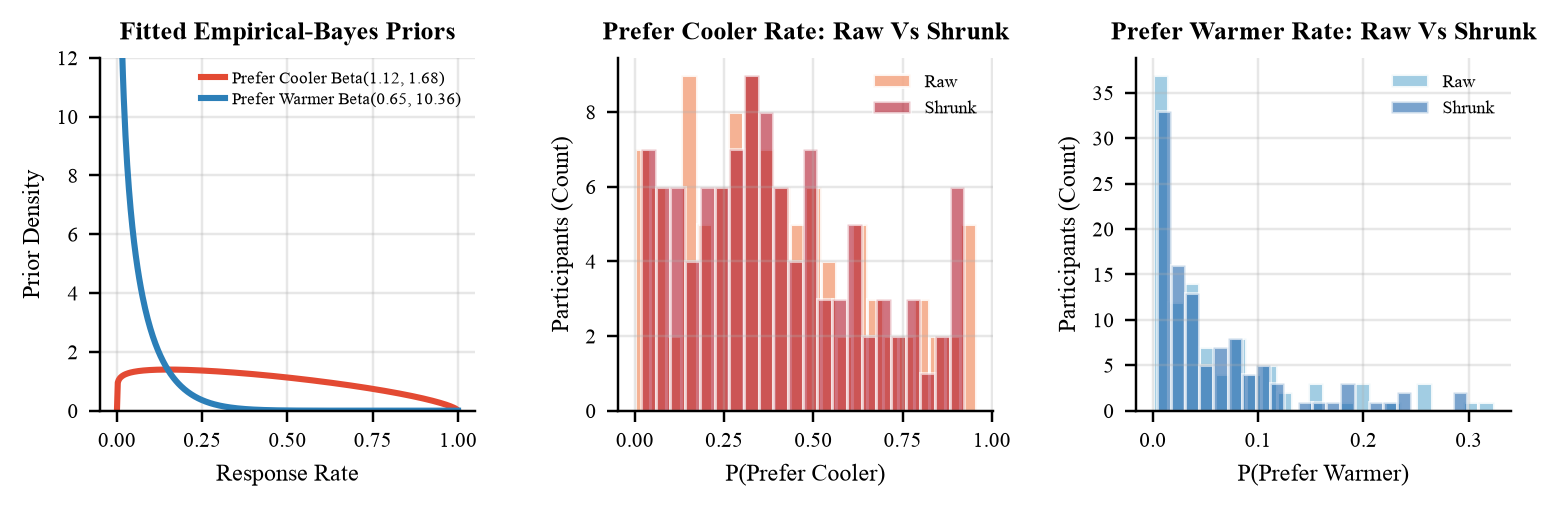

Warmer-rate shrink |Δ| — median 0.005, max 0.036 (largest for the lowest-count participants)


In [37]:
# --- Figure 00_C1 · Fitted EB priors + raw-vs-shrunk rate distributions ------
# Font sizes, titles, labels, legends and spines matched to ground truth.
import os
TS, LS, TK = 8.5, 8, 7                             # title / label / tick font sizes
xx = np.linspace(0, 1, 400)
fig, axes = plt.subplots(1, 3, figsize=(7.16, 2.5))

# (left) fitted Beta prior densities
axes[0].plot(xx, stats.beta.pdf(xx, a_c, b_c), color='#e34a33', lw=2.0,
             label=f'Prefer Cooler Beta({a_c:.2f}, {b_c:.2f})')
axes[0].plot(xx, stats.beta.pdf(xx, a_w, b_w), color='#2c7fb8', lw=2.0,
             label=f'Prefer Warmer Beta({a_w:.2f}, {b_w:.2f})')
axes[0].set_xlabel('Response Rate', fontsize=LS); axes[0].set_ylabel('Prior Density', fontsize=LS)
axes[0].set_title('Fitted Empirical-Bayes Priors', fontsize=TS); axes[0].set_ylim(0, 12)
axes[0].legend(frameon=False, fontsize=5.6, loc='upper right',
               handlelength=1.4, handletextpad=0.4, labelspacing=0.3, borderaxespad=0.4)
axes[0].grid(alpha=0.3)

# (middle) cooler: raw vs shrunk
axes[1].hist(feat['cooler_raw'], bins=22, color='#f4a582', edgecolor='white',
             alpha=0.85, label='Raw')
axes[1].hist(feat['cooler_rate'], bins=22, color='#b2182b', edgecolor='white',
             alpha=0.6, label='Shrunk')
axes[1].set_xlabel('P(Prefer Cooler)', fontsize=LS); axes[1].set_ylabel('Participants (Count)', fontsize=LS)
axes[1].set_title('Prefer Cooler Rate: Raw Vs Shrunk', fontsize=TS)
axes[1].legend(frameon=False, fontsize=6, loc='upper right'); axes[1].grid(alpha=0.3)

# (right) warmer: raw vs shrunk
axes[2].hist(feat['warmer_raw'], bins=22, color='#92c5de', edgecolor='white',
             alpha=0.85, label='Raw')
axes[2].hist(feat['warmer_rate'], bins=22, color='#2166ac', edgecolor='white',
             alpha=0.6, label='Shrunk')
axes[2].set_xlabel('P(Prefer Warmer)', fontsize=LS); axes[2].set_ylabel('Participants (Count)', fontsize=LS)
axes[2].set_title('Prefer Warmer Rate: Raw Vs Shrunk', fontsize=TS)
axes[2].legend(frameon=False, fontsize=6, loc='upper right'); axes[2].grid(alpha=0.3)

# match ground truth: left + bottom axis lines only (drop top/right spines)
for ax in axes:
    ax.tick_params(labelsize=TK)
    ax.spines[['top', 'right']].set_visible(False)

fig.tight_layout()
os.makedirs(str(FIGDIR), exist_ok=True)
fig.savefig(f'{FIGDIR}/00_C1_eb_shrinkage.pdf')
plt.show()

# shrinkage magnitude (how far low-count participants move toward the prior)
mov = (feat['warmer_rate'] - feat['warmer_raw']).abs()
print(f"Warmer-rate shrink |Δ| — median {mov.median():.3f}, max {mov.max():.3f} "
      f"(largest for the lowest-count participants)")

## Part 4 — How Many Archetypes, and the Four-Archetype Solution

We standardize the three features and run k-means for K = 2..6, scoring each by mean silhouette
(supporting diagnostic below). The silhouette is marginally higher at K=3 (0.322) than K=4 (0.316),
but we carry **K=4** forward for mechanistic interpretability: the extra split separates a group whose
cooling demand *rises with heat* (Normatively Responsive) from one that is *genuinely heat-tolerant*
(Heat-Unbothered) — a distinction the scrutiny section tests directly. This is an explicit judgment
call favoring interpretability over a small silhouette margin, not a claim of statistical optimality.

We then fit k-means with K=4 and name the clusters by an interpretable rule on their centroids: the
highest warmer-rate cluster is *Often Over-Cooled* (Captive), the highest remaining cooler-rate is
*Constant Cool-Seekers* (Craver), the highest remaining heat-sensitivity is *Normatively Responsive*
(Conventional), and the last is *Heat-Unbothered* (Carefree). Manuscript **Figures 6** (`00_D2`,
PCA + silhouette) and **7** (`00_D3`, standardized signatures) diagnose the separation.

**Supporting diagnostic — cluster-count selection (silhouette vs K).**

Qualifying participants: 104 of 106 (heat_sensitivity available: 104)


K=2: silhouette=0.272  sizes=[39, 65]
K=3: silhouette=0.322  sizes=[57, 34, 13]
K=4: silhouette=0.316  sizes=[34, 35, 12, 23]
K=5: silhouette=0.308  sizes=[12, 19, 31, 16, 26]
K=6: silhouette=0.285  sizes=[11, 26, 12, 17, 16, 22]


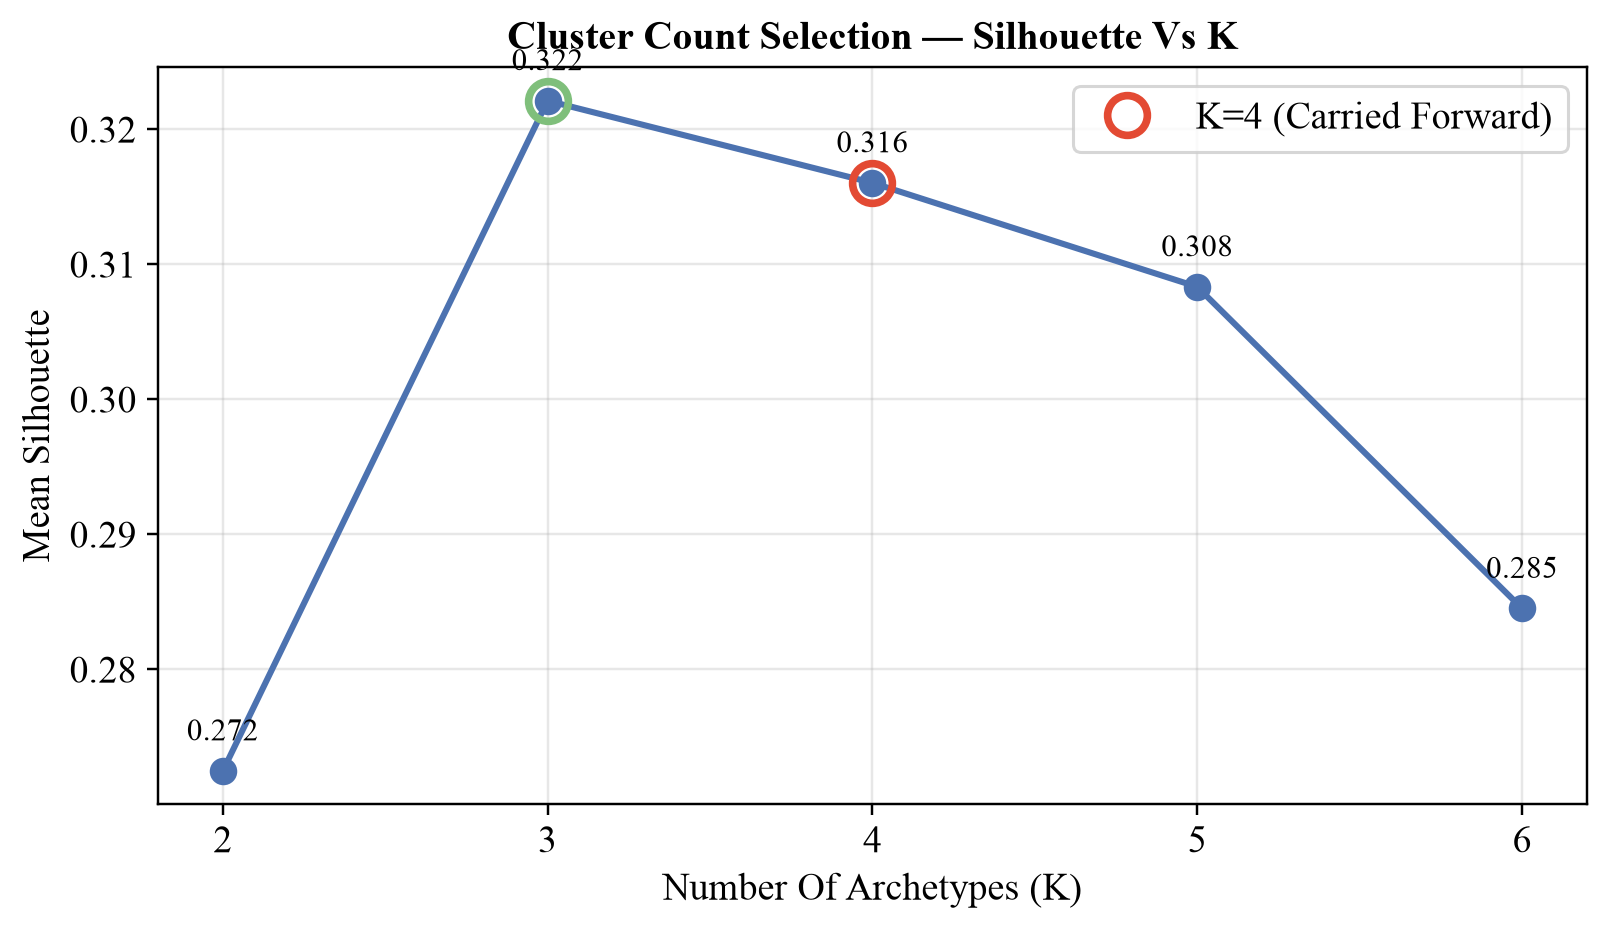

In [38]:
# --- Diagnostic Figure D1 · Cluster-Count Selection: Silhouette Vs K (not exported) ---
ok = (feat['n'] >= 15) & (feat['n_hot'] >= 5) & (feat['n_cool'] >= 5)
qual = feat[ok].copy()
FEATS = ['cooler_rate', 'warmer_rate', 'heat_sensitivity']
X = StandardScaler().fit_transform(qual[FEATS])
print(f"Qualifying participants: {len(qual)} of {len(feat)} "
      f"(heat_sensitivity available: {qual['heat_sensitivity'].notna().sum()})")

Ks = range(2, 7)
sil = {}
for k in Ks:
    lab = KMeans(n_clusters=k, n_init=25, random_state=0).fit(X).labels_
    sil[k] = silhouette_score(X, lab)
    print(f"K={k}: silhouette={sil[k]:.3f}  sizes={np.bincount(lab).tolist()}")

fig, ax = plt.subplots(figsize=(7.5, 4.4))
ks = list(sil); sv = [sil[k] for k in ks]
ax.plot(ks, sv, 'o-', color='#4c72b0', lw=2, ms=8)
ax.plot(3, sil[3], 'o', ms=13, mfc='none', mec='#7fbf7b', mew=2.5)
ax.plot(4, sil[4], 'o', ms=13, mfc='none', mec='#e34a33', mew=2.5,
        label='K=4 (Carried Forward)')
for k in ks:
    ax.annotate(f'{sil[k]:.3f}', (k, sil[k]), textcoords='offset points',
                xytext=(0, 10), ha='center', fontsize=10)
ax.set_xlabel('Number Of Archetypes (K)'); ax.set_ylabel('Mean Silhouette')
ax.set_title('Cluster Count Selection — Silhouette Vs K')
ax.set_xticks(list(ks)); ax.legend(frameon=True); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Manuscript Figure 6 (`00_D2`) — clustering diagnostics (PCA projection + per-archetype silhouette).**  This cell fits K=4, names the clusters, and maps the labels back onto every survey row.

K=4 archetype sizes:
archetype
Constant Cool-Seekers     23
Often Over-Cooled         12
Normatively Responsive    35
Heat-Unbothered           34

Overall mean silhouette (K=4): 0.316

Per-archetype mean silhouette width:
archetype
Constant Cool-Seekers     0.327
Often Over-Cooled         0.329
Normatively Responsive    0.288
Heat-Unbothered           0.333


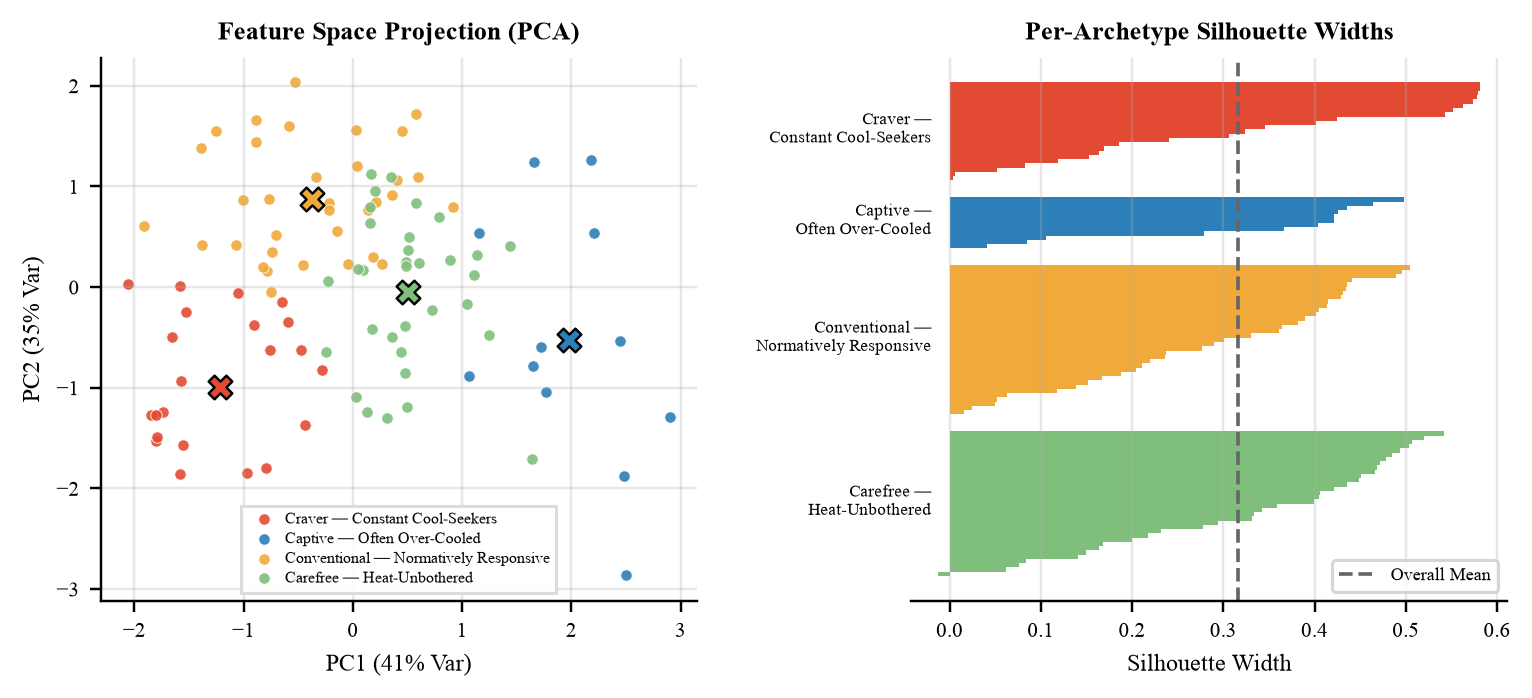

In [39]:
# --- Fit K=4 + interpretable centroid-rule naming (deterministic) -----------
km4 = KMeans(n_clusters=4, n_init=25, random_state=0).fit(X)
qual['km4'] = km4.labels_
cen4 = qual.groupby('km4')[FEATS].mean()
name4 = {}
name4[cen4['warmer_rate'].idxmax()] = 'Often Over-Cooled'
rem = [c for c in cen4.index if c not in name4]; name4[cen4.loc[rem, 'cooler_rate'].idxmax()] = 'Constant Cool-Seekers'
rem = [c for c in cen4.index if c not in name4]; name4[cen4.loc[rem, 'heat_sensitivity'].idxmax()] = 'Normatively Responsive'
name4[[c for c in cen4.index if c not in name4][0]] = 'Heat-Unbothered'
qual['archetype'] = qual['km4'].map(name4)
v['archetype'] = v['id_participant'].map(qual['archetype'])

sizes = qual['archetype'].value_counts().reindex(ORDER4)
print("K=4 archetype sizes:\n" + sizes.to_string())
print(f"\nOverall mean silhouette (K=4): {silhouette_score(X, km4.labels_):.3f}")

sample_sil = silhouette_samples(X, km4.labels_)
qual['sil'] = sample_sil
print("\nPer-archetype mean silhouette width:")
print(qual.groupby('archetype')['sil'].mean().reindex(ORDER4).round(3).to_string())

# --- Figure 00_D2 · (left) PCA feature-space projection, (right) per-archetype
#     silhouette knife plot. Font sizes, labels, layout matched to ground truth.
#     Archetype names/labels come from the setup cell (ARCH_LABEL, APAL, ORDER4).
import os
TS, LS, TK = 8.5, 8, 7                             # title / label / tick font sizes

pca = PCA(n_components=2, random_state=0).fit(X)
XY = pca.transform(X)
evr = pca.explained_variance_ratio_ * 100

fig, axes = plt.subplots(1, 2, figsize=(7.16, 3.36))

# (left) PCA scatter by archetype + projected standardized centroids
for a in ORDER4:
    m = (qual['archetype'] == a).values
    axes[0].scatter(XY[m, 0], XY[m, 1], s=14, color=APAL[a], edgecolor='white',
                    linewidth=0.3, alpha=0.9, label=ARCH_LABEL[a])
cprj = pca.transform(km4.cluster_centers_)
for kk in cen4.index:
    axes[0].scatter(cprj[kk, 0], cprj[kk, 1], marker='X', s=60,
                    color=APAL[name4[kk]], edgecolor='black', linewidth=0.8, zorder=5)
axes[0].set_xlabel(f'PC1 ({evr[0]:.0f}% Var)', fontsize=LS)
axes[0].set_ylabel(f'PC2 ({evr[1]:.0f}% Var)', fontsize=LS)
axes[0].set_title('Feature Space Projection (PCA)', fontsize=TS)
axes[0].tick_params(labelsize=TK)
axes[0].legend(frameon=True, fontsize=5.3, loc='lower center',
               handletextpad=0.3, labelspacing=0.3, borderaxespad=0.5,
               facecolor='white', framealpha=0.9, edgecolor='0.85', fancybox=False)
axes[0].grid(alpha=0.3)

# (right) per-archetype silhouette knife plot
y0 = 0
axes[1].axvline(silhouette_score(X, km4.labels_), color='0.4', ls='--', lw=1.2,
                label='Overall Mean')
for a in reversed(ORDER4):
    vals = np.sort(qual.loc[qual['archetype'] == a, 'sil'].values)
    axes[1].barh(range(y0, y0 + len(vals)), vals, height=1.0, color=APAL[a], edgecolor='none')
    axes[1].text(-0.02, y0 + len(vals) / 2, ARCH_LABEL[a].replace(' — ', ' —\n'),
                 va='center', ha='right', fontsize=5.6)
    y0 += len(vals) + 4
axes[1].set_xlabel('Silhouette Width', fontsize=LS); axes[1].set_yticks([])
axes[1].set_title('Per-Archetype Silhouette Widths', fontsize=TS)
axes[1].tick_params(labelsize=TK)
axes[1].legend(frameon=True, loc='lower right', fontsize=6)
axes[1].grid(axis='x', alpha=0.3)

# match ground truth: left + bottom axis lines only (drop top/right spines)
for ax in axes:
    ax.spines[['top', 'right']].set_visible(False)
axes[1].spines['left'].set_visible(False)   # drop y-axis line running through the archetype labels

fig.tight_layout()
os.makedirs(str(FIGDIR), exist_ok=True)
fig.savefig(f'{FIGDIR}/00_D2_pca_silhouette.pdf')
plt.show()

**Manuscript Figure 7 (`00_D3`) — standardized archetype signatures.**

Standardized feature centroids (z-scores):
                        cooler_rate  warmer_rate  heat_sensitivity
archetype                                                         
Constant Cool-Seekers          1.39        -0.53             -0.55
Often Over-Cooled             -0.32         2.35             -0.28
Normatively Responsive         0.02        -0.27              0.95
Heat-Unbothered               -0.86        -0.19             -0.50


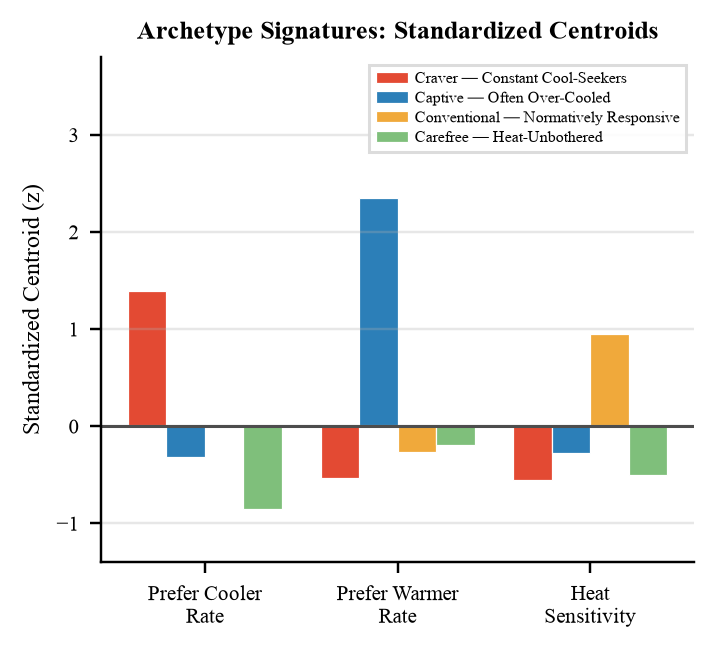

In [40]:
# --- Figure 00_D3 · Standardized centroid profiles (archetype signatures) ----
# Grouped bars of standardized feature centroids per archetype. Font sizes,
# labels, legend and spines matched to the ground-truth manuscript figure.
# Archetype names/labels come from the setup cell (ARCH_LABEL, APAL, ORDER4).
import os
TS, LS, TK = 8.5, 8, 7                             # title / label / tick font sizes

Xz = pd.DataFrame(X, index=qual.index, columns=FEATS)
Xz['archetype'] = qual['archetype']
zc = Xz.groupby('archetype')[FEATS].mean().reindex(ORDER4)
flabel = {'cooler_rate': 'Prefer Cooler\nRate', 'warmer_rate': 'Prefer Warmer\nRate',
          'heat_sensitivity': 'Heat\nSensitivity'}
print("Standardized feature centroids (z-scores):\n" + zc.round(2).to_string())

fig, ax = plt.subplots(figsize=(3.44, 3.15))
xpos = np.arange(len(FEATS)); w = 0.2
for i, a in enumerate(ORDER4):
    ax.bar(xpos + (i - 1.5) * w, zc.loc[a].values, width=w,
           color=APAL[a], edgecolor='white', linewidth=0.4, label=ARCH_LABEL[a])
ax.axhline(0, color='0.3', lw=1)
ax.set_ylim(-1.4, 3.8); ax.set_yticks([-1, 0, 1, 2, 3])   # integer ticks + legend headroom (ground truth)
ax.set_xticks(xpos); ax.set_xticklabels([flabel[f] for f in FEATS], fontsize=TK)
ax.set_ylabel('Standardized Centroid (z)', fontsize=LS)
ax.set_title('Archetype Signatures: Standardized Centroids', fontsize=TS)
ax.tick_params(labelsize=TK)
ax.legend(frameon=True, fontsize=5.3, loc='upper right', ncol=1,
          handletextpad=0.4, labelspacing=0.3, borderaxespad=0.5,
          facecolor='white', framealpha=0.9, edgecolor='0.85', fancybox=False)
ax.grid(axis='y', alpha=0.3)

# match ground truth: left + bottom axis lines only (drop top/right spines)
ax.spines[['top', 'right']].set_visible(False)

fig.tight_layout()
os.makedirs(str(FIGDIR), exist_ok=True)
fig.savefig(f'{FIGDIR}/00_D3_centroid_profiles.pdf')
plt.show()

### Archetype profiles and canonical membership export

The table below profiles the four archetypes on the person-level features, with each group's size and
share (the 22.1 / 11.5 / 33.7 / 32.7 % split reported in the paper). The canonical per-participant
membership is written to `analysis/outputs/` for reference.

In [41]:
import os
# --- Archetype profile table ------------------------------------------------
prof = qual.groupby('archetype').agg(
    n=('n', 'size'),
    surveys_median=('n', 'median'),
    cooler_rate=('cooler_rate', 'mean'),
    warmer_rate=('warmer_rate', 'mean'),
    nochange=('nochange_raw', 'mean'),
    heat_sensitivity=('heat_sensitivity', 'mean'),
    silhouette=('sil', 'mean'),
).reindex(ORDER4)
prof.insert(0, 'mnemonic', [MNEMONIC[a] for a in prof.index])
prof['pct'] = (100 * prof['n'] / len(qual)).round(1)
print("Four-archetype profiles (n=%d participants):\n" % len(qual))
print(prof.round(3).to_string())

# --- Export canonical per-participant membership ----------------------------
out = qual[['n', 'cooler_rate', 'warmer_rate', 'heat_sensitivity', 'archetype']].copy()
out.insert(0, 'mnemonic', out['archetype'].map(MNEMONIC))
out.index.name = 'id_participant'
os.makedirs(str(OUTDIR), exist_ok=True)
outpath = f'{OUTDIR}/home_thermal_archetypes_k4_by_participant.csv'
out.to_csv(outpath)
print(f"\nExported {len(out)} participants → {outpath}")

Four-archetype profiles (n=104 participants):

                            mnemonic   n  surveys_median  cooler_rate  warmer_rate  nochange  heat_sensitivity  silhouette   pct
archetype                                                                                                                       
Constant Cool-Seekers         Craver  23            93.0        0.744        0.024     0.225            -0.029       0.327  22.1
Often Over-Cooled            Captive  12            98.5        0.321        0.210     0.453             0.006       0.329  11.5
Normatively Responsive  Conventional  35            96.0        0.406        0.041     0.555             0.163       0.288  33.7
Heat-Unbothered             Carefree  34            94.5        0.188        0.046     0.774            -0.022       0.333  32.7



Exported 104 participants → /Users/cmiller/Documents/GitHub/cooling-cravers-to-carefree-journal-paper/analysis/outputs/home_thermal_archetypes_k4_by_participant.csv


## Part 5 — Four-Archetype Overview Schematic (Manuscript Figure 5)

Manuscript **Figure 5** (`01_S1`) is the conceptual overview used as the Methods opener: a
representative icon, a schematic behavior sketch, and the size/share of each archetype. It is a
standalone illustration with no analysis dependency (the counts are typed to match the derivation
above).

saved → ../figures/01_S1_archetype_overview.pdf


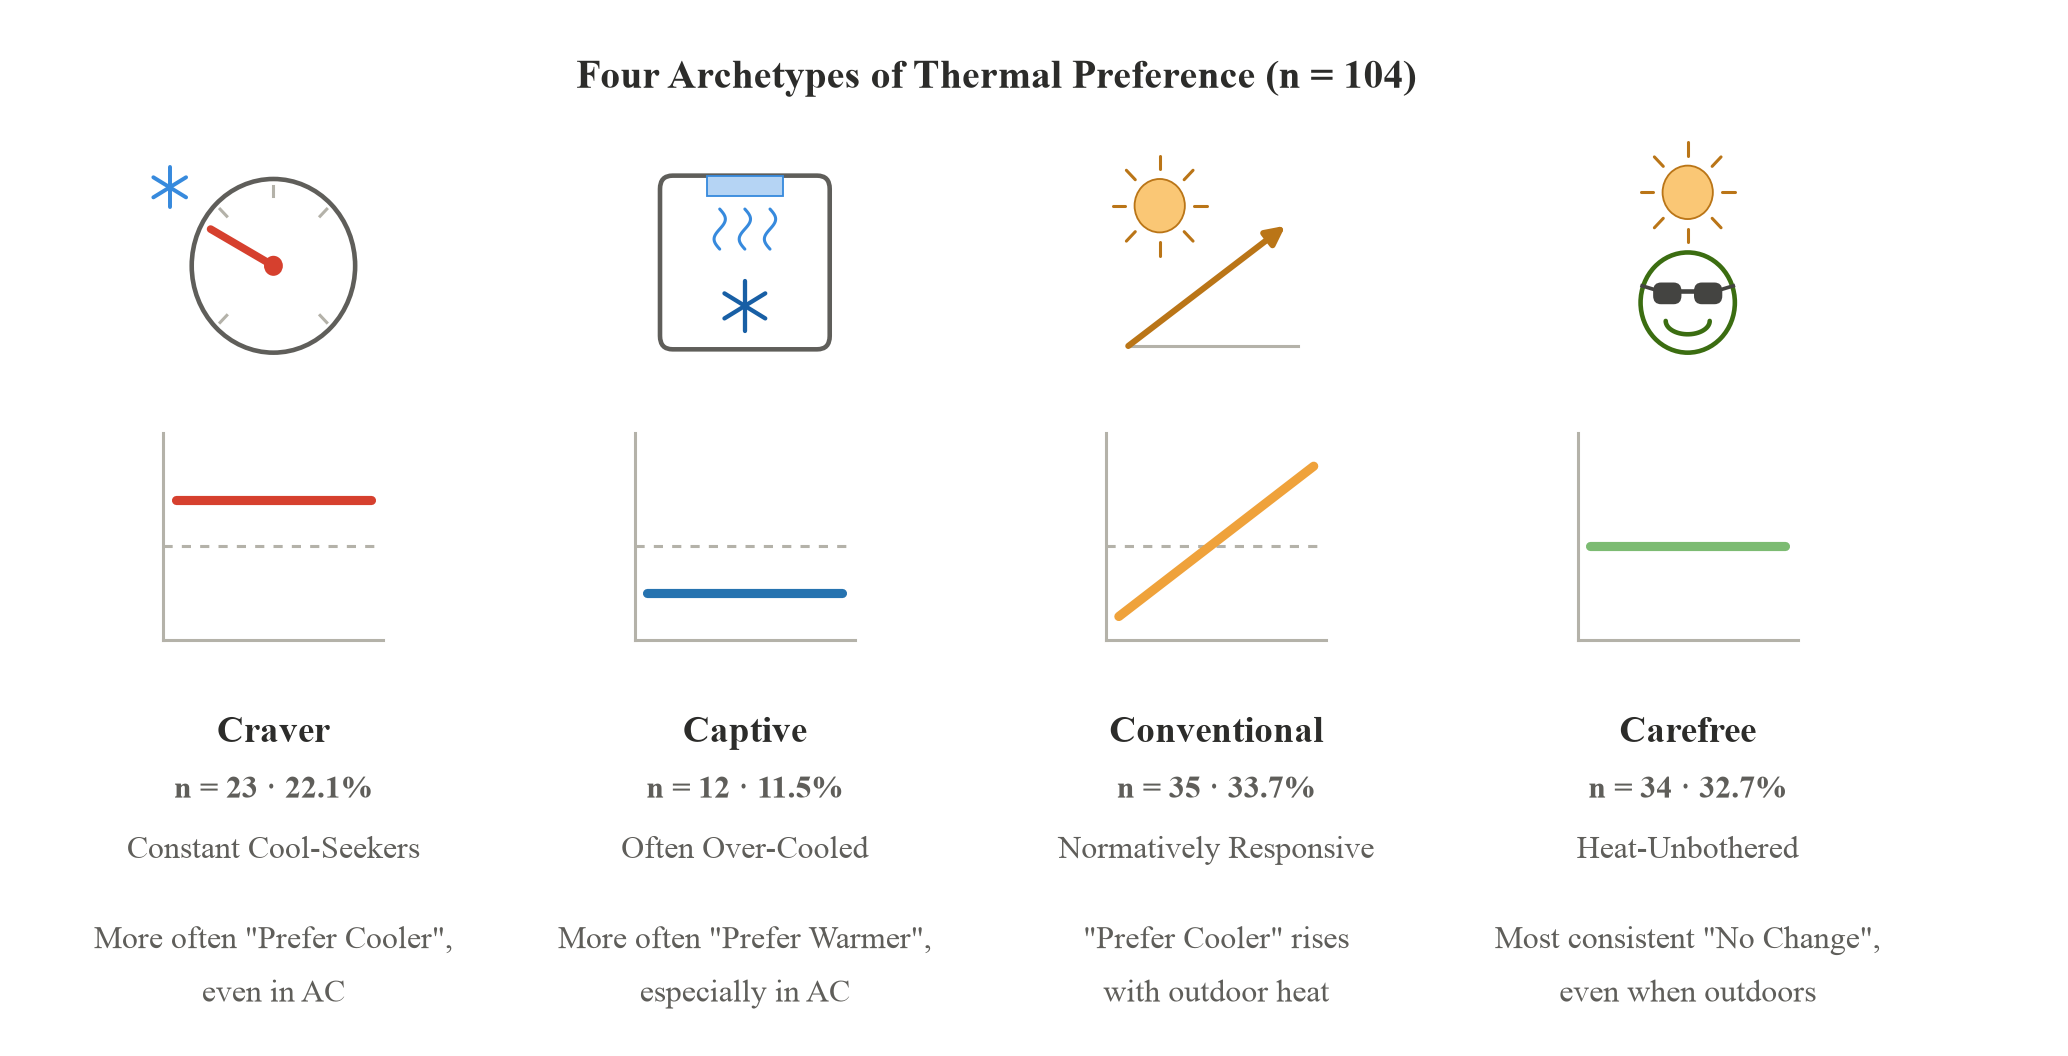

In [42]:
# ============================================================================
# S1 · STANDALONE SCHEMATIC · Four-Archetype Overview (Manuscript Methods Opener)
# Self-contained illustration (no analysis dependencies); kept at the top of the
# notebook. Regenerates figures/01_S1_archetype_overview.pdf.
# ============================================================================
import os
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.font_manager as fm
from matplotlib.lines import Line2D
import numpy as np

RED, BLUE, AMBER, GREEN = "#D6402E", "#2673B0", "#EFA23B", "#7CBB72"
DARKAMBER = "#BA7517"
GRAY, LGRAY, DGRAY = "#5F5E5A", "#B4B2A9", "#2C2C2A"
SNOW = "#378ADD"

fig = plt.figure(figsize=(9.2, 4.6))
ax = fig.add_axes([0, 0, 1, 1])
ax.set_xlim(30, 674)
ax.set_ylim(318, 15)
ax.axis("off")

fs_title, fs_name, fs_sub = 13, 12, 10.5
_avail = {f.name for f in fm.fontManager.ttflist}
FONT = next((f for f in ["Times New Roman", "Nimbus Roman No9 L", "Liberation Serif",
                         "DejaVu Serif"] if f in _avail), "serif")

ax.text(340, 32, "Four Archetypes of Thermal Preference (n = 104)",
        ha="center", va="center", fontsize=fs_title, fontweight="bold",
        color=DGRAY, family=FONT)

def snowflake(cx, cy, r, color, lw):
    for ang in (90, 30, 150):
        a = np.radians(ang)
        dx, dy = r*np.cos(a), r*np.sin(a)
        ax.add_line(Line2D([cx-dx, cx+dx], [cy-dy, cy+dy], color=color,
                           lw=lw, solid_capstyle="round"))

def sun(cx, cy, r, ray):
    ax.add_patch(mpatches.Circle((cx, cy), r, facecolor="#FAC775",
                 edgecolor=DARKAMBER, lw=0.6))
    for ang in range(0, 360, 45):
        a = np.radians(ang)
        x1, y1 = cx + (r+3)*np.cos(a), cy + (r+3)*np.sin(a)
        x2, y2 = cx + (r+3+ray)*np.cos(a), cy + (r+3+ray)*np.sin(a)
        ax.add_line(Line2D([x1, x2], [y1, y2], color=DARKAMBER, lw=1,
                           solid_capstyle="round"))

# ---- Icon row ----
cx, cy = 110, 88
ax.add_patch(mpatches.Circle((cx, cy), 26, facecolor="none", edgecolor=GRAY, lw=1.5))
for ang in (90, 45, 135, -45, -135):
    a = np.radians(ang)
    x1, y1 = cx + 21*np.cos(a), cy - 21*np.sin(a)
    x2, y2 = cx + 24*np.cos(a), cy - 24*np.sin(a)
    ax.add_line(Line2D([x1, x2], [y1, y2], color=LGRAY, lw=1))
ax.add_line(Line2D([cx, cx-20], [cy, cy-11], color=RED, lw=2.5, solid_capstyle="round"))
ax.add_patch(mpatches.Circle((cx, cy), 3, facecolor=RED, edgecolor="none"))
snowflake(77, 64.5, 6, SNOW, 1.3)

ax.add_patch(mpatches.FancyBboxPatch((233, 61), 54, 52,
             boxstyle="round,pad=0,rounding_size=4", facecolor="none", edgecolor=GRAY, lw=1.5))
ax.add_patch(mpatches.Rectangle((248, 61), 24, 6, facecolor="#B5D4F4", edgecolor=SNOW, lw=0.6))
for x0 in (252, 260, 268):
    t = np.linspace(0, 1, 30)
    ax.plot(x0 + 1.8*np.sin(t*2*np.pi), 71 + 12*t, color=SNOW, lw=1, solid_capstyle="round")
snowflake(260, 100, 7.5, "#185FA5", 1.4)

sun(392, 70, 8, 4)
ax.add_line(Line2D([382, 436], [112, 112], color=LGRAY, lw=1))
ax.annotate("", xy=(432, 76), xytext=(382, 112),
            arrowprops=dict(arrowstyle="-|>", color=DARKAMBER, lw=2, shrinkA=0, shrinkB=0))

sun(560, 66, 8, 4)
ax.add_patch(mpatches.Circle((560, 99), 15, facecolor="none", edgecolor="#3B6D11", lw=1.5))
for x0 in (549, 562):
    ax.add_patch(mpatches.FancyBboxPatch((x0, 93), 9, 6.5,
                 boxstyle="round,pad=0,rounding_size=2.5", facecolor="#444441", edgecolor="none"))
ax.add_line(Line2D([558, 562], [95.5, 95.5], color="#444441", lw=1.5))
ax.add_line(Line2D([549, 545.5], [95, 94], color="#444441", lw=1.2))
ax.add_line(Line2D([571, 574.5], [95, 94], color="#444441", lw=1.2))
t = np.linspace(0, np.pi, 30)
ax.plot(560 + 7*np.cos(t), 106 + 4*np.sin(t) - 1.5, color="#3B6D11", lw=1.5, solid_capstyle="round")

# ---- Trend glyph row ----
def trend(x0, line_y=None, slope=None, color=RED, neutral=True):
    ax.add_line(Line2D([x0, x0], [138, 200], color=LGRAY, lw=1))
    ax.add_line(Line2D([x0, x0+70], [200, 200], color=LGRAY, lw=1))
    if neutral:
        ax.add_line(Line2D([x0, x0+70], [172, 172], color=LGRAY, lw=1, linestyle=(0, (3, 3))))
    if slope:
        ax.add_line(Line2D([x0+4, x0+66], slope, color=color, lw=3, solid_capstyle="round"))
    else:
        ax.add_line(Line2D([x0+4, x0+66], [line_y, line_y], color=color, lw=3, solid_capstyle="round"))

trend(75, line_y=158, color=RED)
trend(225, line_y=186, color=BLUE)
trend(375, slope=[193, 148], color=AMBER)
trend(525, line_y=172, color=GREEN, neutral=False)

# ---- Text columns ----
cols = [
    (110, "Craver", "Constant Cool-Seekers", "n = 23 \u00b7 22.1%",
     'More often "Prefer Cooler",', "even in AC"),
    (260, "Captive", "Often Over-Cooled", "n = 12 \u00b7 11.5%",
     'More often "Prefer Warmer",', "especially in AC"),
    (410, "Conventional", "Normatively Responsive", "n = 35 \u00b7 33.7%",
     '"Prefer Cooler" rises', "with outdoor heat"),
    (560, "Carefree", "Heat-Unbothered", "n = 34 \u00b7 32.7%",
     'Most consistent "No Change",', "even when outdoors"),
]
for x, mnem, name, n, p1, p2 in cols:
    ax.text(x, 228, mnem, ha="center", va="center", fontsize=fs_name,
            fontweight="bold", color=DGRAY, family=FONT)
    ax.text(x, 245, n, ha="center", va="center", fontsize=fs_sub,
            fontweight="bold", color=GRAY, family=FONT)
    ax.text(x, 263, name, ha="center", va="center", fontsize=fs_sub, color=GRAY, family=FONT)
    ax.text(x, 290, p1, ha="center", va="center", fontsize=fs_sub, color=GRAY, family=FONT)
    ax.text(x, 306, p2, ha="center", va="center", fontsize=fs_sub, color=GRAY, family=FONT)

os.makedirs(str(FIGDIR), exist_ok=True)
fig.savefig(f"{FIGDIR}/01_S1_archetype_overview.pdf", format="pdf")
print("saved → ../figures/01_S1_archetype_overview.pdf")

## Part 6 — Mechanistic Scrutiny

The four archetypes were derived from behavior alone. The scrutiny places responses back in their
thermal and environmental context and tests whether each group behaves as its name implies. We use the
Singapore control taxonomy — Singapore offices, classrooms, and public transport are overwhelmingly
air-conditioned — ordering contexts by increasing air-conditioning likelihood. Uncertainty is reported
as 95% **cluster-bootstrap** confidence intervals that resample whole participants, so no comparison
treats participant-nested responses as independent.

First we bridge from the derivation to the survey-level scrutiny frame, adding the home over-cooling
rate and a per-survey archetype label, and gate the pipeline on the manuscript's headline cohort
numbers.

In [43]:
# --- Bridge: home over-cooling rate + per-survey archetype labels + QC gate ---
_home = v[v['q_location'] == HOME]
_hg = _home.groupby('id_participant')
feat['home_n'] = _hg.size().reindex(feat.index).fillna(0).astype(int)
feat['home_warmer_raw'] = _hg['warmer'].mean().reindex(feat.index)
feat.loc[feat['home_n'] < 5, 'home_warmer_raw'] = np.nan
qual['home_warmer_raw'] = feat['home_warmer_raw']

# survey rows carrying an archetype label (the 104 archetyped participants)
va = v[v['archetype'].notna()].copy()

# QC gate — reproduce the manuscript's headline cohort numbers exactly
_sizes = qual['archetype'].value_counts().to_dict()
_expected = {'Normatively Responsive': 35, 'Heat-Unbothered': 34,
             'Constant Cool-Seekers': 23, 'Often Over-Cooled': 12}
assert len(v) == 9520, f"valid rows {len(v)} != 9520"
assert v['id_participant'].nunique() == 106, "participant count != 106"
assert round(HImed, 1) == 34.1, f"median heat index {HImed} != 34.1"
assert len(qual) == 104, f"qualifying {len(qual)} != 104"
assert _sizes == _expected, f"cluster sizes {_sizes} != {_expected}"
print("QC passed — 9,520 rows | 106 participants | heat-index median 34.1 °C | 104 qualifying")
print("Archetype sizes:", {MNEMONIC[a]: _sizes[a] for a in ORDER4}, "| scrutiny survey rows:", len(va))

QC passed — 9,520 rows | 106 participants | heat-index median 34.1 °C | 104 qualifying
Archetype sizes: {'Craver': 23, 'Captive': 12, 'Conventional': 35, 'Carefree': 34} | scrutiny survey rows: 9358


Scrutiny helpers: the control-context taxonomy, display markers/labels, figure-size helpers, the statistics utilities (Wilson intervals, participant cluster-bootstrap, Cliff's delta), and the outdoor-heat sextiles used by the dose-response figures.

In [44]:
# --- Scrutiny setup: taxonomy, display helpers, statistics, and heat sextiles ---
from matplotlib.lines import Line2D

ARCH_MARK = {'Constant Cool-Seekers': 'o', 'Often Over-Cooled': 'X',
             'Normatively Responsive': '^', 'Heat-Unbothered': 's'}
ARCH_TICK = {a: f'{MNEMONIC[a]} —\n{a}' for a in ORDER4}
order4 = ORDER4                                             # lowercase alias used in reused cells

# 4-category probable-control-context taxonomy (increasing A/C likelihood)
CONTROL = {'Outdoor':         'Outdoor\n(No A/C)',
           'Indoor - Home':   'Home\n(Maybe A/C)',
           'Indoor - Office': 'Office/Class/Other\n(Likely A/C)',
           'Indoor - Class':  'Office/Class/Other\n(Likely A/C)',
           'Indoor - Other':  'Office/Class/Other\n(Likely A/C)',
           'Transportation':  'Transport\n(Very Likely A/C)'}
CTX = ['Outdoor\n(No A/C)', 'Home\n(Maybe A/C)',
       'Office/Class/Other\n(Likely A/C)', 'Transport\n(Very Likely A/C)']
ctx_short = {c: c.replace('\n', ' ') for c in CTX}
v['control']  = v['q_location'].map(CONTROL)
va['control'] = va['q_location'].map(CONTROL)
sub = va[va['control'].isin(CTX)].copy()

# figure-size helpers (single/double column, inches) + PDF saver → analysis/figures
COL_W, FULL_W = 3.44, 7.16
def fs(kind, h):      return (COL_W if kind == 'col' else FULL_W, h)
def fig_name(tag, s): return f'01_{tag}_{s}'
def savepdf(fig, name):
    os.makedirs(FIGDIR, exist_ok=True)
    fig.savefig(f'{FIGDIR}/{name}.pdf', format='pdf', bbox_inches='tight')

# statistics helpers reused across figures
def wilson(k, n, z=1.96):
    if n == 0: return (np.nan, np.nan, np.nan)
    p = k / n; d = 1 + z**2 / n
    c = (p + z**2 / (2 * n)) / d
    h = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / d
    return p, c - h, c + h

def cluster_ci(frame, statfn, B=1000, seed=0):
    # 95% participant cluster-bootstrap CI for a Series-returning statistic
    rng = np.random.default_rng(seed)
    parts = np.array(sorted(frame['id_participant'].unique()))
    pid = frame['id_participant'].values
    idx = {p: np.where(pid == p)[0] for p in parts}
    base = statfn(frame)
    arr = np.full((B, len(base)), np.nan)
    for b in range(B):
        take = np.concatenate([idx[p] for p in rng.choice(parts, len(parts), replace=True)])
        arr[b] = statfn(frame.iloc[take]).reindex(base.index).values
    lo = pd.Series(np.nanpercentile(arr, 2.5, axis=0), index=base.index)
    hi = pd.Series(np.nanpercentile(arr, 97.5, axis=0), index=base.index)
    return lo, hi

def cliffs_delta(a, b):
    a = np.asarray(a, float); b = np.asarray(b, float)
    a = a[~np.isnan(a)]; b = b[~np.isnan(b)]
    if len(a) == 0 or len(b) == 0: return np.nan
    gt = (a[:, None] > b[None, :]).sum()
    lt = (a[:, None] < b[None, :]).sum()
    return (gt - lt) / (len(a) * len(b))

# outdoor-heat sextiles (used by the dose-response figures)
NBIN = 6
va['heat_bin'] = pd.qcut(va['heat_index_mean_1h'], NBIN, labels=False)
bin_centers = va.groupby('heat_bin')['heat_index_mean_1h'].mean()
MINN = 10
print("Scrutiny frame:", len(va), "survey rows | 4-context subset:", len(sub))
print("Surveys by control context:\n" + va['control'].value_counts().reindex(CTX).to_string())

Scrutiny frame: 9358 survey rows | 4-context subset: 9358
Surveys by control context:
control
Outdoor\n(No A/C)                   1017
Home\n(Maybe A/C)                   4223
Office/Class/Other\n(Likely A/C)    3509
Transport\n(Very Likely A/C)         609


### Section A — Cooling Demand and Relief From Air-Conditioning

Splitting surveys by control context, we read P(Prefer Cooler) per context. The prediction: cooling
demand should *fall* as spaces become more likely to be air-conditioned (relief), except for the
Craver, whose demand should stay high even in air-conditioned space. Manuscript **Figure 8** (`01_A3`)
shows this across five contexts with 95% cluster-bootstrap intervals.

**Manuscript Figure 8 (`01_A3`) — prefer-cooler responses across probable control contexts.**

P(Cooler) by 5-way control context, % (point estimate):
                        Outdoor\n(No A/C)  Home\n(Maybe A/C)  Indoor Other\n(Maybe A/C)  Office/Classroom\n(Likely A/C)  Transport\n(Likely A/C)
Constant Cool-Seekers                75.9               81.9                       64.9                            64.2                     69.5
Often Over-Cooled                    53.3               32.8                       40.3                            22.9                     37.2
Normatively Responsive               61.7               44.8                       31.1                            32.8                     36.8
Heat-Unbothered                      31.5               18.4                       15.6                            11.0                     19.9


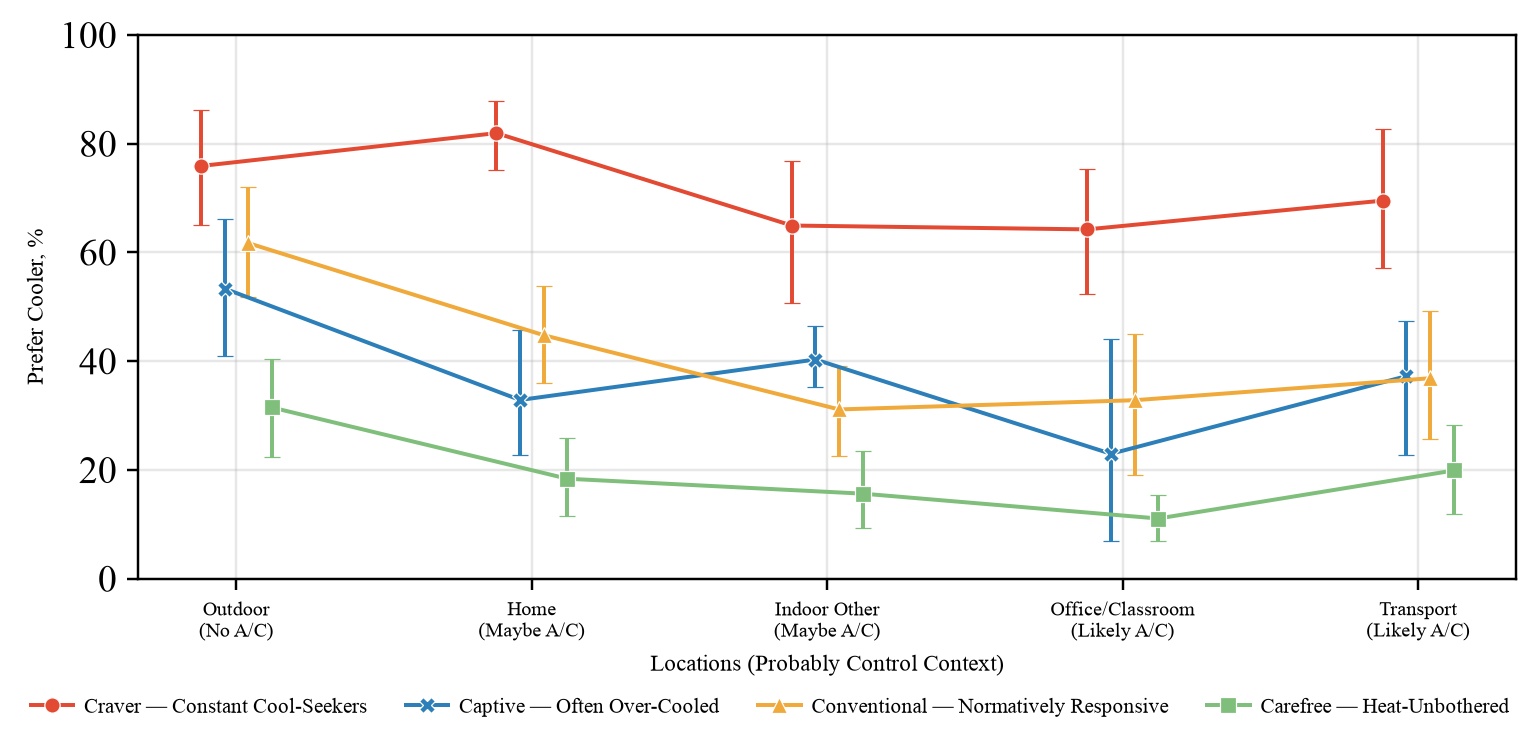

In [45]:
# ============================================================================
# --- Figure 01_A3 · Relief From Air-Conditioning (Alternative 5-Context View) ---
# ============================================================================
CONTROL5 = {'Outdoor':         'Outdoor\n(No A/C)',
            'Indoor - Home':   'Home\n(Maybe A/C)',
            'Indoor - Other':  'Indoor Other\n(Maybe A/C)',
            'Indoor - Office': 'Office/Classroom\n(Likely A/C)',
            'Indoor - Class':  'Office/Classroom\n(Likely A/C)',
            'Transportation':  'Transport\n(Likely A/C)'}
CTX5 = ['Outdoor\n(No A/C)', 'Home\n(Maybe A/C)', 'Indoor Other\n(Maybe A/C)',
        'Office/Classroom\n(Likely A/C)', 'Transport\n(Likely A/C)']

va5 = va.copy(); va5['control5'] = va5['q_location'].map(CONTROL5)
sub5 = va5[va5['control5'].isin(CTX5)].copy()

def pcooler_ctx5(frame):
    return (frame.groupby(['archetype', 'control5'])['cooler'].mean()
                 .reindex(pd.MultiIndex.from_product([ORDER4, CTX5])) * 100)
point = pcooler_ctx5(sub5)
lo, hi = cluster_ci(sub5, pcooler_ctx5, B=1000, seed=0)
P = point.unstack().reindex(index=ORDER4, columns=CTX5)
LO = lo.unstack().reindex(index=ORDER4, columns=CTX5)
HI = hi.unstack().reindex(index=ORDER4, columns=CTX5)
print("P(Cooler) by 5-way control context, % (point estimate):\n" + P.round(1).to_string())

fig, ax = plt.subplots(figsize=fs('full', 3.6))
x = np.arange(len(CTX5))
for i, a in enumerate(ORDER4):
    y = P.loc[a].values
    yerr = np.vstack([y - LO.loc[a].values, HI.loc[a].values - y])
    ax.errorbar(x + (i - 1.5) * 0.08, y, yerr=yerr, fmt='-', marker=ARCH_MARK[a], color=APAL[a],
                lw=1.3, ms=5, capsize=2.5, markeredgecolor='white', markeredgewidth=0.4,
                label=ARCH_LABEL[a])
ax.set_xticks(x); ax.set_xticklabels(CTX5, fontsize=6.5)
ax.set_xlabel('Locations (Probably Control Context)', fontsize=7.5)
ax.set_ylabel('Prefer Cooler, %', fontsize=7.5); ax.set_ylim(0, 100)
ax.grid(alpha=0.3)
handles = [Line2D([0], [0], color=APAL[a], marker=ARCH_MARK[a], lw=1.3, ms=5,
                  markeredgecolor='white', markeredgewidth=0.4) for a in ORDER4]
fig.tight_layout(rect=(0, 0.07, 1, 1))
fig.legend(handles, [ARCH_LABEL[a] for a in ORDER4], loc='lower center',
           bbox_to_anchor=(0.5, 0.045), ncol=4, frameon=False, fontsize=7,
           handletextpad=0.5, columnspacing=1.8)
savepdf(fig, fig_name('A3', 'relief_by_context_5cat')); plt.show()

### Section B — Over-Cooling Anatomy

The Captive hypothesis says their "too cold" votes come from environments someone else controls, not
from the weather. Manuscript **Figure 9** (`01_B1`) plots P(Prefer Warmer) by control context per
archetype, and reports the Captive's over-cooling gradient (likely-A/C minus outdoor) with a
cluster-bootstrap interval.

**Manuscript Figure 9 (`01_B1`) — over-cooling anatomy by control context.**

P(Warmer / too cold) by control context, %:
                        Outdoor\n(No A/C)  Home\n(Maybe A/C)  Office/Class/Other\n(Likely A/C)  Transport\n(Very Likely A/C)
Constant Cool-Seekers                 3.1                0.6                               3.6                           1.2
Often Over-Cooled                    20.8               19.8                              28.0                          13.8
Normatively Responsive                0.6                2.7                               6.5                           4.2
Heat-Unbothered                       6.5                2.1                               5.8                           3.7



Captive over-cooling gradient (Office/Class/Other Likely-A/C − Outdoor): +7.2 pts  [95% CI -19.6, +29.6]


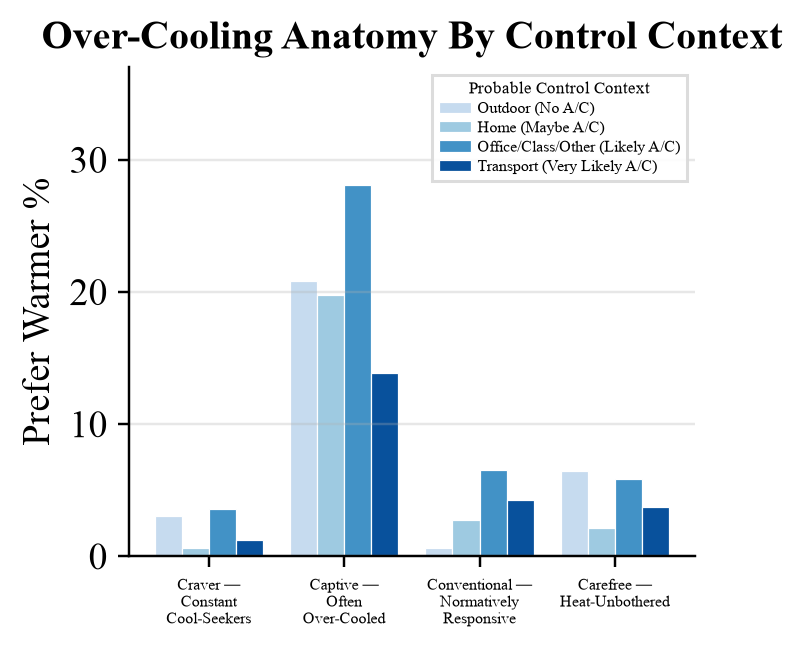

In [46]:
# ============================================================================
# --- Figure 01_B1 · Over-Cooling Anatomy ---
# ============================================================================
def pwarmer_ctx(frame):
    return (frame.groupby(['archetype', 'control'])['warmer'].mean()
                 .reindex(pd.MultiIndex.from_product([ORDER4, CTX])) * 100)
PW = pwarmer_ctx(sub).unstack().reindex(index=ORDER4, columns=CTX)
print("P(Warmer / too cold) by control context, %:\n" + PW.round(1).to_string())

cap = 'Often Over-Cooled'
def cap_gradient(frame):
    s = frame[frame['archetype'] == cap]
    a = s.loc[s['control'] == CTX[2], 'warmer'].mean()
    o = s.loc[s['control'] == CTX[0], 'warmer'].mean()
    return pd.Series({'grad': (a - o) * 100})
g_pt = cap_gradient(sub)['grad']
g_lo, g_hi = cluster_ci(sub, cap_gradient, B=1000, seed=1)
print(f"\nCaptive over-cooling gradient (Office/Class/Other Likely-A/C − Outdoor): "
      f"{g_pt:+.1f} pts  [95% CI {g_lo['grad']:+.1f}, {g_hi['grad']:+.1f}]")

fig, ax = plt.subplots(figsize=fs('col', 3.15))
x = np.arange(len(ORDER4)); w = 0.2
ctx_col = ['#c6dbef', '#9ecae1', '#4292c6', '#08519c']
b1_leg = {c: ctx_short[c] for c in CTX}
for i, ctx in enumerate(CTX):
    ax.bar(x + (i - 1.5) * w, PW[ctx].values, width=w, color=ctx_col[i],
           edgecolor='white', linewidth=0.4, label=b1_leg[ctx])
ax.set_xticks(x)
B1_TICK = {'Constant Cool-Seekers': 'Craver —\nConstant\nCool-Seekers',
           'Often Over-Cooled':      'Captive —\nOften\nOver-Cooled',
           'Normatively Responsive': 'Conventional —\nNormatively\nResponsive',
           'Heat-Unbothered':        'Carefree —\nHeat-Unbothered'}
ax.set_xticklabels([B1_TICK[a] for a in ORDER4], fontsize=5.2)
ax.set_ylabel('Prefer Warmer %')
ax.set_ylim(0, float(np.nanmax(PW.values)) * 1.32)
ax.set_title('Over-Cooling Anatomy By Control Context')
ax.legend(title='Probable Control Context', loc='upper right', ncol=1, fontsize=5.3,
          title_fontsize=5.6, handletextpad=0.4, labelspacing=0.28, borderaxespad=0.5,
          facecolor='white', framealpha=0.9, edgecolor='0.85', fancybox=False)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)   # match other figures: left + bottom spines only
fig.tight_layout()
savepdf(fig, fig_name('B1', 'overcooling_anatomy')); plt.show()

### Section C — Heat Dose-Response and Coupling

The central discriminator: how P(Prefer Cooler) moves with outdoor heat. We trace the dose-response
across heat sextiles within three control supergroups (manuscript **Figure 10**, `01_C3`) and distill
it into a single **heat coupling** per archetype, P(Cooler | hot) − P(Cooler | not-hot), with 95%
cluster-bootstrap intervals (manuscript **Figure 11**, `01_C2`).

**Manuscript Figure 10 (`01_C3`) — dose-response of prefer-cooler vs outdoor heat, by control supergroup.**

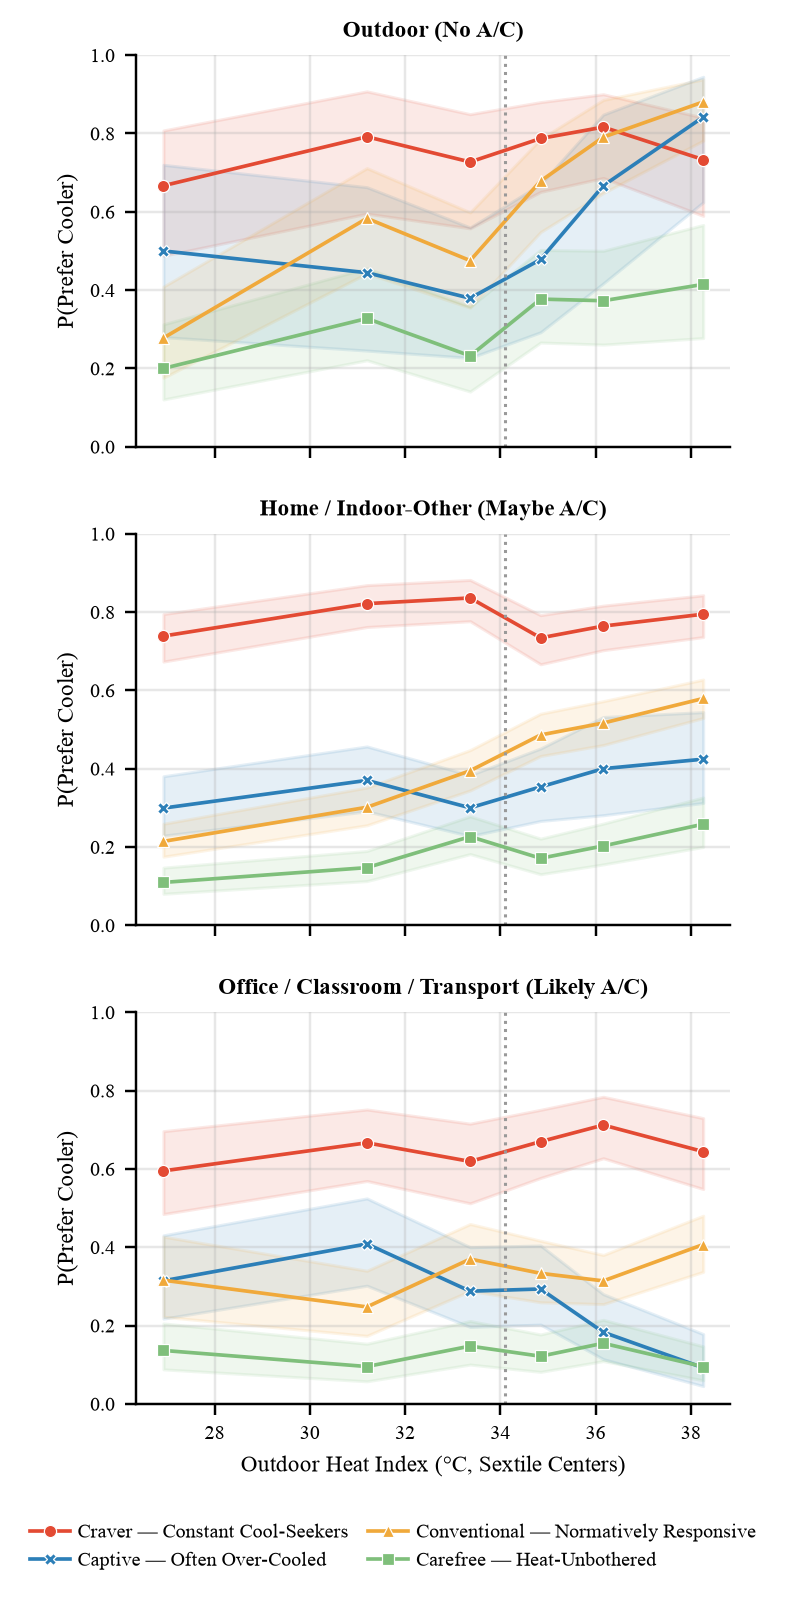

In [47]:
# ============================================================================
# --- Figure 01_C3 · Dose Response, By 3 A/C-Likelihood Supergroups ---
# ============================================================================
CONTROL3B = {'Outdoor':         'Outdoor\n(No A/C)',
             'Indoor - Home':   'Home / Indoor-Other\n(Maybe A/C)',
             'Indoor - Other':  'Home / Indoor-Other\n(Maybe A/C)',
             'Indoor - Office': 'Office / Classroom / Transport\n(Likely A/C)',
             'Indoor - Class':  'Office / Classroom / Transport\n(Likely A/C)',
             'Transportation':  'Office / Classroom / Transport\n(Likely A/C)'}
CTX3B = ['Outdoor\n(No A/C)', 'Home / Indoor-Other\n(Maybe A/C)',
         'Office / Classroom / Transport\n(Likely A/C)']

va3 = va.copy(); va3['control3b'] = va3['q_location'].map(CONTROL3B)
d3 = va3[va3['control3b'].isin(CTX3B)]

fig, axes = plt.subplots(3, 1, figsize=(COL_W, 7.4), sharex=True)
for ax, ctx in zip(axes, CTX3B):
    dd = d3[d3['control3b'] == ctx]
    for a in ORDER4:
        s0 = dd[dd['archetype'] == a]
        rows = []
        for b in range(NBIN):
            s = s0[s0['heat_bin'] == b]
            if len(s) >= MINN:
                p, lo, hi = wilson(s['cooler'].sum(), len(s))
                rows.append((bin_centers[b], p, lo, hi))
        if not rows:
            continue
        xx, pp, lo, hi = np.array(rows).T
        ax.plot(xx, pp, '-', marker=ARCH_MARK[a], color=APAL[a], lw=1.2, ms=4,
                markeredgecolor='white', markeredgewidth=0.4, label=ARCH_LABEL[a])
        ax.fill_between(xx, lo, hi, color=APAL[a], alpha=0.12)
    ax.axvline(HImed, color='0.6', ls=':', lw=1)
    ax.set_ylabel('P(Prefer Cooler)', fontsize=7.5); ax.set_ylim(0, 1); ax.grid(alpha=0.3)
    ax.set_title(ctx.replace(chr(10), ' '), fontsize=7.5)
    ax.tick_params(labelsize=6.5)
    ax.spines[['top', 'right']].set_visible(False)
axes[-1].set_xlabel('Outdoor Heat Index (°C, Sextile Centers)', fontsize=7.5)
handles = [Line2D([0], [0], color=APAL[a], marker=ARCH_MARK[a], lw=1.2, ms=4,
                  markeredgecolor='white', markeredgewidth=0.4) for a in ORDER4]
fig.tight_layout(rect=(0, 0.055, 1, 1))
fig.legend(handles, [ARCH_LABEL[a] for a in ORDER4], loc='lower center',
           bbox_to_anchor=(0.5, 0.012), ncol=2, frameon=False,
           handletextpad=0.4, columnspacing=1.0, fontsize=6.5)
savepdf(fig, fig_name('C3', 'dose_response_heat_3super')); plt.show()

**Manuscript Figure 11 (`01_C2`) — heat coupling by archetype.**

Heat coupling  P(Cooler|hot) − P(Cooler|not-hot)  [95% cluster-bootstrap CI]:
  Constant Cool-Seekers    -0.000  [-0.072, +0.071]
  Often Over-Cooled        -0.014  [-0.120, +0.088]
  Normatively Responsive   +0.181  [+0.106, +0.248]
  Heat-Unbothered          +0.032  [-0.013, +0.075]


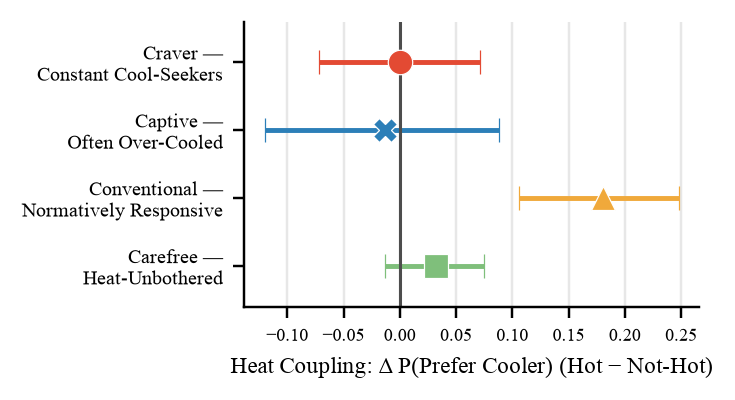

In [48]:
# ============================================================================
# --- Figure 01_C2 · Heat Coupling By Archetype (95% Cluster-Bootstrap CI) ---
# Coupling = P(Cooler | hot) − P(Cooler | not-hot), participant cluster-bootstrap.
# ============================================================================
def coupling(frame):
    out = {}
    for a in ORDER4:
        s = frame[frame['archetype'] == a]
        h, c = s[s['hot'] == 1]['cooler'], s[s['hot'] == 0]['cooler']
        out[a] = h.mean() - c.mean() if len(h) and len(c) else np.nan
    return pd.Series(out).reindex(ORDER4)
point = coupling(va)
lo, hi = cluster_ci(va, coupling, B=1000, seed=1)
res = pd.DataFrame({'coupling': point, 'lo': lo.reindex(ORDER4), 'hi': hi.reindex(ORDER4)})
print("Heat coupling  P(Cooler|hot) − P(Cooler|not-hot)  [95% cluster-bootstrap CI]:")
for a in ORDER4:
    print(f"  {a:24s} {res.loc[a,'coupling']:+.3f}  [{res.loc[a,'lo']:+.3f}, {res.loc[a,'hi']:+.3f}]")

fig, ax = plt.subplots(figsize=fs('col', 2.0))
y = np.arange(len(ORDER4))[::-1]
for a, yy in zip(ORDER4, y):
    ax.errorbar(res.loc[a, 'coupling'], yy,
                xerr=[[res.loc[a, 'coupling'] - res.loc[a, 'lo']], [res.loc[a, 'hi'] - res.loc[a, 'coupling']]],
                fmt=ARCH_MARK[a], color=APAL[a], ms=8, capsize=4, lw=1.6,
                markeredgecolor='white', markeredgewidth=0.4)
ax.axvline(0, color='0.3', lw=1)
ax.set_yticks(y); ax.set_yticklabels([ARCH_TICK[a] for a in ORDER4], fontsize=6.5)
ax.set_ylim(-0.6, 3.6)                          # headroom so Craver/Carefree markers clear the edges
ax.set_xlabel('Heat Coupling: Δ P(Prefer Cooler) (Hot − Not-Hot)', fontsize=7.5)
ax.locator_params(axis='x', nbins=10)           # denser x ticks
ax.tick_params(axis='x', labelsize=6)
ax.grid(axis='x', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)  # left + bottom spines only (match other figures)
fig.tight_layout()
savepdf(fig, fig_name('C2', 'heat_coupling')); plt.show()

### Section D — Exposure and Provoked Comfort

The decisive test for the Carefree: are they "always happy" because they are never exposed to heat, or
genuinely tolerant? Manuscript **Figure 12** (`01_D1`) compares outdoor-exposure share across
archetypes (Kruskal–Wallis) against P(No change) when hot and when outdoors.

**Manuscript Figure 12 (`01_D1`) — outdoor exposure and provoked comfort by archetype.**

Median outdoor-exposure share, %:
archetype
Constant Cool-Seekers     11.0
Often Over-Cooled         11.2
Normatively Responsive    10.0
Heat-Unbothered           11.0

Kruskal H=0.66, p=0.883, epsilon^2=-0.023

P(No Change) | Hot / Outdoors, %:
                         Hot  Outdoors
archetype                             
Constant Cool-Seekers   24.0      21.1
Often Over-Cooled       41.1      25.8
Normatively Responsive  45.4      37.7
Heat-Unbothered         75.8      62.1


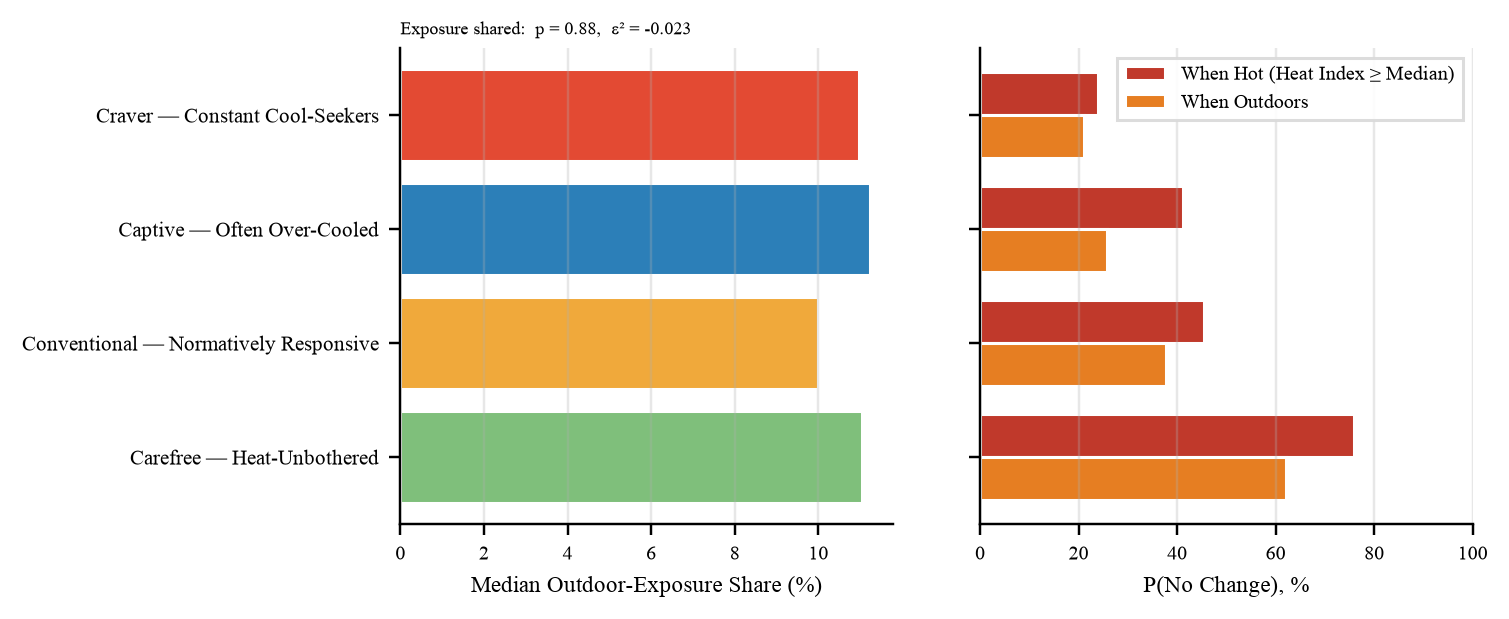

In [49]:
# ============================================================================
# --- Figure 01_D1 · Exposure Equality + Provoked Comfort (Heat-Unbothered) ---
# Left: per-participant outdoor-exposure share (Kruskal p, ε² computed live).
# Right: P(No Change) when hot and when outdoors, per archetype.
# ============================================================================
expo = va.groupby('id_participant').agg(outdoor_share=('outdoor', 'mean'),
                                        archetype=('archetype', 'first'))
groups = [expo.loc[expo['archetype'] == a, 'outdoor_share'].values for a in ORDER4]
H, p_expo = stats.kruskal(*groups)
Ntot = len(expo); eps2 = (H - len(ORDER4) + 1) / (Ntot - len(ORDER4))
med_expo = expo.groupby('archetype')['outdoor_share'].median().reindex(ORDER4) * 100
pnc_hot = va[va['hot'] == 1].groupby('archetype')['nochange'].mean().reindex(ORDER4) * 100
pnc_out = va[va['outdoor'] == 1].groupby('archetype')['nochange'].mean().reindex(ORDER4) * 100
print("Median outdoor-exposure share, %:\n" + med_expo.round(1).to_string())
print(f"\nKruskal H={H:.2f}, p={p_expo:.3f}, epsilon^2={eps2:.3f}")
print("\nP(No Change) | Hot / Outdoors, %:")
print(pd.DataFrame({'Hot': pnc_hot.round(1), 'Outdoors': pnc_out.round(1)}).to_string())

fig, axes = plt.subplots(1, 2, figsize=fs('full', 3.0), sharey=True)
yy = np.arange(len(ORDER4))[::-1]

# Left - outdoor-exposure share (horizontal bars); exposure-equality stat kept as annotation
axes[0].barh(yy, med_expo.values, color=[APAL[a] for a in ORDER4], edgecolor='white')
axes[0].set_yticks(yy); axes[0].set_yticklabels([ARCH_LABEL[a] for a in ORDER4], fontsize=7)
axes[0].set_xlabel('Median Outdoor-Exposure Share (%)', fontsize=7.5)
axes[0].tick_params(axis='x', labelsize=6.5)
axes[0].grid(axis='x', alpha=0.3)
axes[0].spines[['top', 'right']].set_visible(False)
axes[0].annotate(f'Exposure shared:  p = {p_expo:.2f},  \u03b5\u00b2 = {eps2:.3f}',
                 xy=(0.0, 1.02), xycoords='axes fraction', ha='left', va='bottom', fontsize=6)

# Right - P(No Change) when hot / outdoors (horizontal grouped bars, shared archetype y-axis)
w = 0.38
axes[1].barh(yy + w/2, pnc_hot.values, w, color='#c0392b', edgecolor='white',
             label='When Hot (Heat Index \u2265 Median)')
axes[1].barh(yy - w/2, pnc_out.values, w, color='#e67e22', edgecolor='white', label='When Outdoors')
axes[1].set_xlabel('P(No Change), %', fontsize=7.5); axes[1].set_xlim(0, 100)
axes[1].tick_params(axis='x', labelsize=6.5)
axes[1].legend(frameon=True, fontsize=6.5, facecolor='white', framealpha=0.9,
               edgecolor='0.85', fancybox=False, loc='upper right')
axes[1].grid(axis='x', alpha=0.3)
axes[1].spines[['top', 'right']].set_visible(False)
fig.tight_layout(w_pad=2.0)
savepdf(fig, fig_name('D1', 'exposure_provoked_comfort')); plt.show()

### Section E — Independent Behaviors and Wearable Physiology

If the archetypes are a genuine behavioral construct rather than an artifact, they should show
structure on **independent survey behaviors** never used to cluster (manuscript **Figure 13**,
`01_E1`) yet remain **undifferentiated on wearable physiology** (manuscript **Figure 14**, `01_E3`) —
a null result that is expected and reassuring.

**Manuscript Figure 13 (`01_E1`) — independent survey behaviors by archetype.**

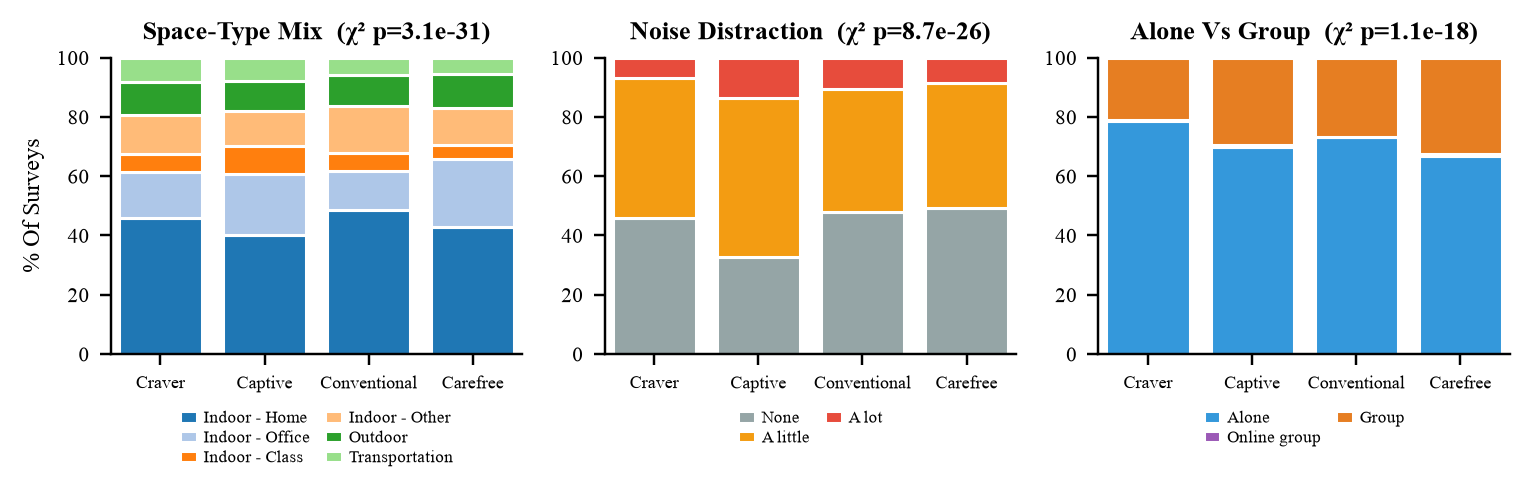

In [50]:
# ============================================================================
# --- Figure 01_E1 · Archetype Differences On INDEPENDENT Survey Behaviour ---
# Variables NOT used to cluster (space-type mix, noise distraction, alone-vs-
# group); 100% stacked bars per archetype with a chi-square test per panel.
# Style matched to the ground-truth manuscript figure (Times New Roman, LB spines).
# ============================================================================
specs = [
    ('q_location', ['Indoor - Home', 'Indoor - Office', 'Indoor - Class', 'Indoor - Other', 'Outdoor', 'Transportation'],
     plt.cm.tab20.colors[:6], 'Space-Type Mix'),
    ('q_noise_nearby', ['None', 'A little', 'A lot'], ['#95a5a6', '#f39c12', '#e74c3c'], 'Noise Distraction'),
    ('q_alone_group', ['Alone', 'Online group', 'Group'], ['#3498db', '#9b59b6', '#e67e22'], 'Alone Vs Group'),
]
TS, LS, TK, XT, LG = 8.5, 8, 7, 6, 5.5             # title / ylabel / ytick / xtick / legend fonts

fig, axes = plt.subplots(1, 3, figsize=(7.16, 2.5))
for ax, (colname, corder, colors, title) in zip(axes, specs):
    comp = (pd.crosstab(va['archetype'], va[colname], normalize='index')
            .reindex(index=ORDER4, columns=corder, fill_value=0) * 100)
    bottom = np.zeros(len(ORDER4)); x = np.arange(len(ORDER4))
    for cat, c in zip(corder, colors):
        ax.bar(x, comp[cat].values, bottom=bottom, color=c, edgecolor='white', label=cat, width=0.8)
        bottom += comp[cat].values
    _, p, _, _ = stats.chi2_contingency(pd.crosstab(va['archetype'], va[colname]).reindex(ORDER4))
    ax.set_xticks(x); ax.set_xticklabels([MNEMONIC[a] for a in ORDER4], fontsize=XT)
    ax.set_ylim(0, 100); ax.margins(x=0.02)
    ax.set_title(f'{title}  (\u03c7\u00b2 p={p:.1e})', fontsize=TS)
    ax.tick_params(axis='y', labelsize=TK)
    ax.legend(fontsize=LG, ncol=2, loc='upper center', bbox_to_anchor=(0.5, -0.14), frameon=False,
              handlelength=1.0, handletextpad=0.4, columnspacing=0.9, labelspacing=0.25)
    ax.spines[['top', 'right']].set_visible(False)

axes[0].set_ylabel('% Of Surveys', fontsize=LS)   # y-label only on left panel
fig.tight_layout()
fig.subplots_adjust(bottom=0.32, wspace=0.2)
os.makedirs(str(FIGDIR), exist_ok=True)
fig.savefig(f'{FIGDIR}/01_E1_independent_behaviours.pdf')
plt.show()

**Manuscript Figure 14 (`01_E3`) — wearable physiology in the hour before each survey.**

Wearable physiology by archetype (Kruskal ε², p):
  Resting HR Proxy (bpm)   eps2=0.024  p=0.49
  Mean HR (bpm)            eps2=0.020  p=0.57
  HR Std. Dev. (bpm)       eps2=0.015  p=0.67
  Movement (Steps/h, Log)  eps2=0.009  p=0.82


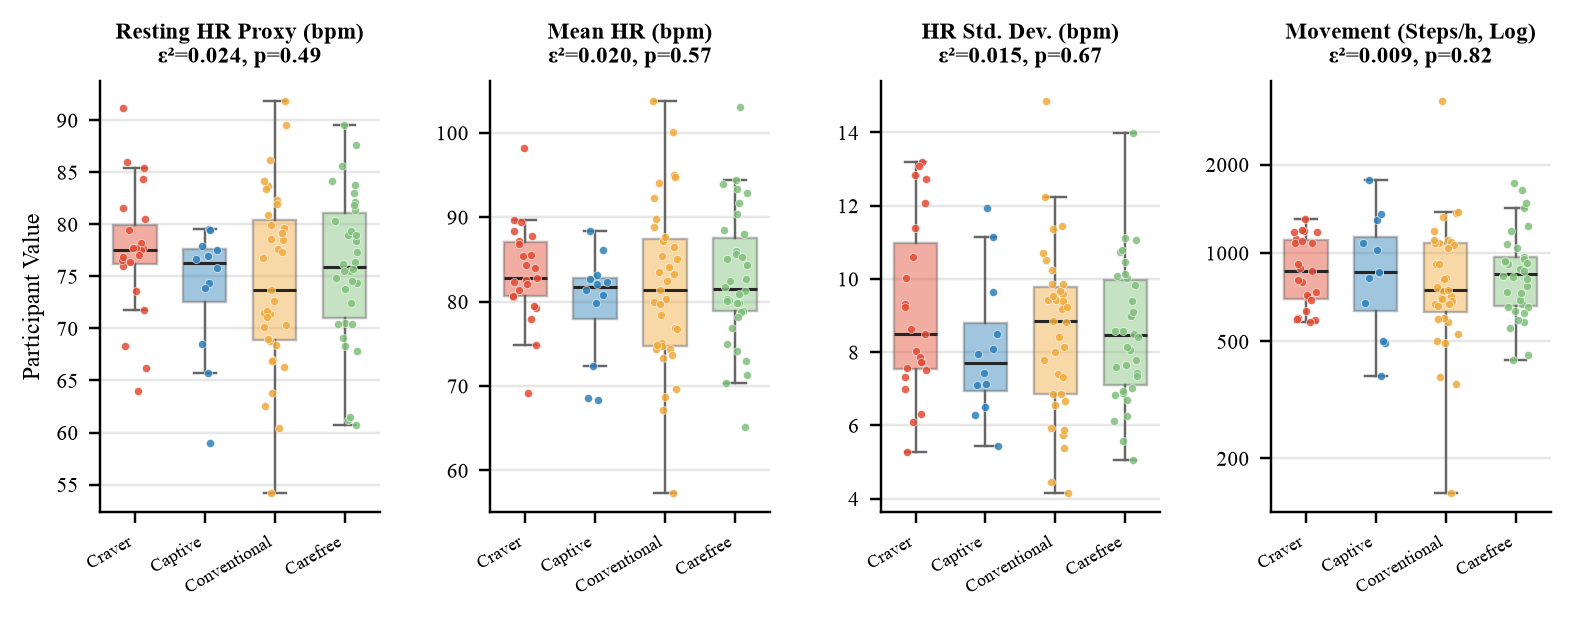

In [51]:
# ============================================================================
# --- Figure 01_E3 · Wearable Physiology In The 1 h Before Each Survey ---
# Per-participant medians by archetype; Kruskal-Wallis ε² = H/(N-1), p per panel.
# Null result: archetypes are a behavioural construct, not a physiological one.
# ============================================================================
step_med = va['steps_total_1h'].median()
low = va[va['steps_total_1h'] <= step_med]          # low-activity rows → resting-HR proxy
pp = pd.DataFrame({
    'archetype':  va.groupby('id_participant')['archetype'].first(),
    'rhr_proxy':  low.groupby('id_participant')['hr_mean_1h'].mean(),
    'mean_hr':    va.groupby('id_participant')['hr_mean_1h'].mean(),
    'hr_std':     va.groupby('id_participant')['hr_std_1h'].mean(),
    'steps':      va.groupby('id_participant')['steps_total_1h'].mean(),
})

def kw_eps2(col):
    gps = [pp.loc[pp['archetype'] == a, col].dropna().values for a in ORDER4]
    H, p = stats.kruskal(*gps)
    N = sum(len(g) for g in gps)
    return H / (N - 1), p                            # standard epsilon-squared (>=0)

panels = [('rhr_proxy', 'Resting HR Proxy (bpm)', False),
          ('mean_hr',   'Mean HR (bpm)',          False),
          ('hr_std',    'HR Std. Dev. (bpm)',     False),
          ('steps',     'Movement (Steps/h, Log)', True)]

import matplotlib.ticker as mticker
fig, axes = plt.subplots(1, 4, figsize=(7.34, 3.02))   # width/size harmonized with 02_B1
rng = np.random.default_rng(0)
print("Wearable physiology by archetype (Kruskal ε², p):")
for ax, (col, lab, logy) in zip(axes, panels):
    for i, a in enumerate(ORDER4):
        yv = pp.loc[pp['archetype'] == a, col].dropna().values
        ax.boxplot(yv, positions=[i], widths=0.62, showfliers=False, patch_artist=True,
                   boxprops=dict(facecolor=APAL[a], edgecolor='0.4', linewidth=0.8, alpha=0.45),
                   whiskerprops=dict(color='0.4', linewidth=0.8),
                   capprops=dict(color='0.4', linewidth=0.8),
                   medianprops=dict(color='0.15', linewidth=1.0))
        ax.scatter(i + rng.uniform(-0.18, 0.18, len(yv)), yv, s=7, color=APAL[a],
                   edgecolor='white', linewidth=0.2, alpha=0.85, zorder=3)
    e, p = kw_eps2(col)
    print(f"  {lab:24s} eps2={e:.3f}  p={p:.2f}")
    if logy:
        ax.set_yscale('log')
        ax.yaxis.set_major_locator(mticker.LogLocator(base=10, subs=(1, 2, 5)))
        ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
        ax.yaxis.set_minor_locator(mticker.NullLocator())
    ax.set_xticks(range(4)); ax.set_xticklabels([MNEMONIC[a] for a in ORDER4], rotation=30, ha='right', fontsize=6)
    ax.set_title(f'{lab}\n\u03b5\u00b2={e:.3f}, p={p:.2f}', fontsize=7.5)
    ax.tick_params(axis='y', labelsize=7)
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)
axes[0].set_ylabel('Participant Value', fontsize=8)
fig.tight_layout()
savepdf(fig, fig_name('E3', 'hr_and_movement_by_archetype')); plt.show()

## Part 7 — Robustness and Boundary Membership

The paper positions the archetypes as a descriptive behavioral typology, not a hard classifier. These
checks support that reading: the K=4 partition is seed-stable (adjusted Rand index ≈ 0.94) and
reproduces under 90% subsampling (≈ 0.77), while exact membership is more sensitive to the hot/cool
threshold (≈ 0.47–0.65 as the split moves off the median) — the ranges quoted in the manuscript's
robustness subsection. Cliff's delta confirms each archetype is near-maximally separated on its own
signature feature. (These are supporting diagnostics, not manuscript figures.)

B2 seed stability   (50 seeds)      : ARI median 0.941 [min 0.745], identical-to-seed0 in 14% of seeds
B3 subsample (90%) stability (200x) : ARI median 0.771 [IQR 0.674–0.883, min 0.486]


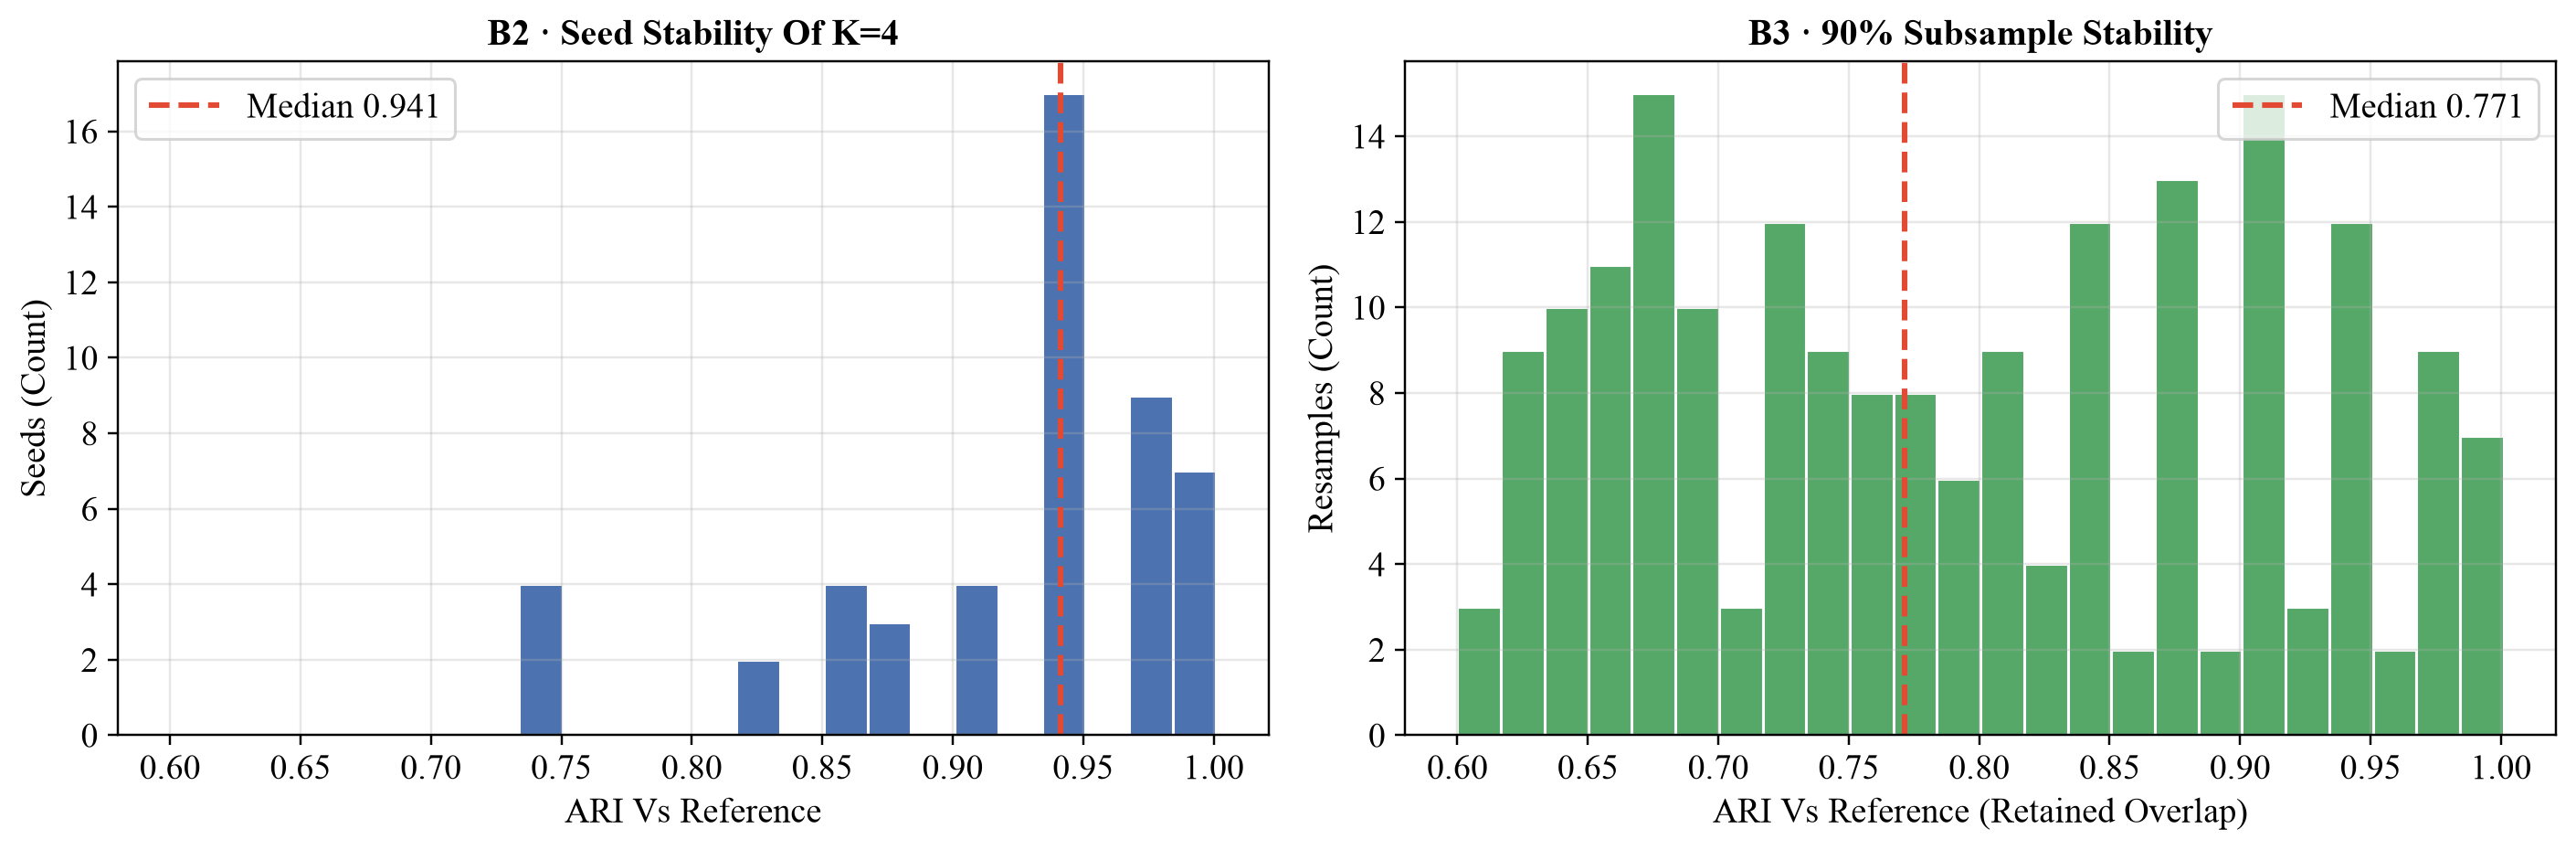

In [52]:
# ============================================================================
# B2 — seed stability of the K=4 partition ; B3 — 90% subsample stability (ARI)
# ============================================================================
ref = qual['km4'].values                     # reference K=4 labels (seed 0)

# B2: refit with many seeds, ARI vs reference (ARI is label-permutation invariant)
seed_ari = []
for s in range(1, 51):
    lab_s = KMeans(n_clusters=4, n_init=25, random_state=s).fit(X).labels_
    seed_ari.append(adjusted_rand_score(ref, lab_s))
seed_ari = np.array(seed_ari)

# B3: drop a random 10% of participants, refit, ARI on the retained overlap
rng = np.random.default_rng(2)
nsub = int(round(0.9 * len(qual)))
sub_ari = []
for r in range(200):
    sel = rng.choice(len(qual), nsub, replace=False)
    lab_r = KMeans(n_clusters=4, n_init=10, random_state=0).fit(X[sel]).labels_
    sub_ari.append(adjusted_rand_score(ref[sel], lab_r))
sub_ari = np.array(sub_ari)

print(f"B2 seed stability   (50 seeds)      : ARI median {np.median(seed_ari):.3f} "
      f"[min {seed_ari.min():.3f}], identical-to-seed0 in {100*np.mean(seed_ari>0.999):.0f}% of seeds")
print(f"B3 subsample (90%) stability (200x) : ARI median {np.median(sub_ari):.3f} "
      f"[IQR {np.percentile(sub_ari,25):.3f}–{np.percentile(sub_ari,75):.3f}, min {sub_ari.min():.3f}]")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
axes[0].hist(seed_ari, bins=np.linspace(0.6, 1.001, 25), color='#4c72b0', edgecolor='white')
axes[0].axvline(np.median(seed_ari), color='#e34a33', ls='--', lw=2,
                label=f'Median {np.median(seed_ari):.3f}')
axes[0].set_xlabel('ARI Vs Reference'); axes[0].set_ylabel('Seeds (Count)')
axes[0].set_title('B2 · Seed Stability Of K=4'); axes[0].legend(frameon=True); axes[0].grid(alpha=0.3)
axes[1].hist(sub_ari, bins=np.linspace(0.6, 1.001, 25), color='#55a868', edgecolor='white')
axes[1].axvline(np.median(sub_ari), color='#e34a33', ls='--', lw=2,
                label=f'Median {np.median(sub_ari):.3f}')
axes[1].set_xlabel('ARI Vs Reference (Retained Overlap)'); axes[1].set_ylabel('Resamples (Count)')
axes[1].set_title('B3 · 90% Subsample Stability'); axes[1].legend(frameon=True); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [53]:
# ============================================================================
# B4 — alternative specification: rebuild features+clusters under a different
#      hot/cool threshold and measure agreement (ARI) with the main solution
# ============================================================================
def build_labels(hot_q):
    vv = v.copy()
    thr = vv['heat_index_mean_1h'].quantile(hot_q)
    vv['hot2'] = (vv['heat_index_mean_1h'] >= thr).astype(int)
    gg = vv.groupby('id_participant')
    f = pd.DataFrame({'n': gg.size(), 'n_hot': gg['hot2'].sum(),
                      'cooler_x': gg['cooler'].sum(), 'warmer_x': gg['warmer'].sum()})
    f['n_cool'] = f['n'] - f['n_hot']
    def hs(s):
        h, c = s[s['hot2'] == 1], s[s['hot2'] == 0]
        return h['cooler'].mean() - c['cooler'].mean() if len(h) >= 5 and len(c) >= 5 else np.nan
    f['heat_sensitivity'] = gg.apply(hs, include_groups=False)
    ac, bc = eb_beta_prior(f['cooler_x'], f['n']); aw, bw = eb_beta_prior(f['warmer_x'], f['n'])
    f['cooler_rate'] = shrink(f['cooler_x'], f['n'], ac, bc)
    f['warmer_rate'] = shrink(f['warmer_x'], f['n'], aw, bw)
    m = (f['n'] >= 15) & (f['n_hot'] >= 5) & (f['n_cool'] >= 5)
    q = f[m].copy()
    Xa = StandardScaler().fit_transform(q[FEATS])
    q['km'] = KMeans(n_clusters=4, n_init=25, random_state=0).fit(Xa).labels_
    return q

for hq in [0.45, 0.55, 0.60]:
    q2 = build_labels(hq)
    common = qual.index.intersection(q2.index)
    ari = adjusted_rand_score(qual.loc[common, 'km4'], q2.loc[common, 'km'])
    print(f"Hot threshold = {int(hq*100)}th pct: qualifying {len(q2)}, "
          f"overlap {len(common)}, ARI vs main = {ari:.3f}")

# ============================================================================
# B5 — pairwise archetype effect sizes (Cliff's delta) on discriminating features
# ============================================================================
def cliffs_delta(a, b):
    a, b = np.asarray(a), np.asarray(b)
    gt = sum((a[:, None] > b[None, :]).sum(1)); lt = sum((a[:, None] < b[None, :]).sum(1))
    return (gt - lt) / (len(a) * len(b))

print("\nB5 · Cliff's delta between archetypes (rows vs cols):")
for feat_name in ['cooler_rate', 'heat_sensitivity']:
    M = pd.DataFrame(index=ORDER4, columns=ORDER4, dtype=float)
    for i in ORDER4:
        for j in ORDER4:
            M.loc[i, j] = cliffs_delta(qual.loc[qual['archetype'] == i, feat_name],
                                       qual.loc[qual['archetype'] == j, feat_name])
    print(f"\n  [{feat_name}]\n" + M.astype(float).round(2).to_string())

Hot threshold = 45th pct: qualifying 105, overlap 104, ARI vs main = 0.650
Hot threshold = 55th pct: qualifying 103, overlap 103, ARI vs main = 0.513


Hot threshold = 60th pct: qualifying 96, overlap 96, ARI vs main = 0.469

B5 · Cliff's delta between archetypes (rows vs cols):

  [cooler_rate]
                        Constant Cool-Seekers  Often Over-Cooled  Normatively Responsive  Heat-Unbothered
Constant Cool-Seekers                    0.00               0.98                    0.90             1.00
Often Over-Cooled                       -0.98               0.00                   -0.36             0.59
Normatively Responsive                  -0.90               0.36                    0.00             0.70
Heat-Unbothered                         -1.00              -0.59                   -0.70             0.00

  [heat_sensitivity]
                        Constant Cool-Seekers  Often Over-Cooled  Normatively Responsive  Heat-Unbothered
Constant Cool-Seekers                    0.00              -0.09                   -0.90            -0.02
Often Over-Cooled                        0.09               0.00                   -0.59   

Per-participant scrutiny metrics (labels, exposure, provoked comfort, heat coupling) are exported for reference.

In [54]:
import os
# ============================================================================
# EXPORT — per-participant scrutiny table (labels + key scrutiny metrics)
# ============================================================================
pnc_hot_pp = va[va['hot'] == 1].groupby('id_participant')['nochange'].mean()
pcool_hot_pp = va[va['hot'] == 1].groupby('id_participant')['cooler'].mean()
pcool_cool_pp = va[va['hot'] == 0].groupby('id_participant')['cooler'].mean()
expo = va.groupby('id_participant').agg(outdoor_share=('outdoor', 'mean'))

scr = qual[['n', 'cooler_rate', 'warmer_rate', 'heat_sensitivity', 'home_warmer_raw', 'archetype']].copy()
scr.insert(0, 'mnemonic', scr['archetype'].map(MNEMONIC))
scr['outdoor_share'] = expo['outdoor_share']
scr['p_nochange_when_hot'] = pnc_hot_pp
scr['p_cooler_when_hot'] = pcool_hot_pp
scr['heat_coupling'] = pcool_hot_pp - pcool_cool_pp
scr.index.name = 'id_participant'

os.makedirs(str(OUTDIR), exist_ok=True)
outpath = f'{OUTDIR}/thermal_archetypes_k4_scrutiny_by_participant.csv'
scr.round(4).to_csv(outpath)
print(f"Exported {len(scr)} participants × {scr.shape[1]} columns → {outpath}")
print(scr.groupby('archetype')[['outdoor_share', 'p_nochange_when_hot', 'heat_coupling']]
      .mean().reindex(ORDER4).round(3).to_string())

Exported 104 participants × 11 columns → /Users/cmiller/Documents/GitHub/cooling-cravers-to-carefree-journal-paper/analysis/outputs/thermal_archetypes_k4_scrutiny_by_participant.csv
                        outdoor_share  p_nochange_when_hot  heat_coupling
archetype                                                                
Constant Cool-Seekers           0.113                0.233         -0.029
Often Over-Cooled               0.101                0.403          0.006
Normatively Responsive          0.103                0.468          0.163
Heat-Unbothered                 0.126                0.772         -0.022


## Part 8 — Do Onboarding Traits Predict Archetype Membership?

Finally we test whether stable **onboarding traits** — personality, life satisfaction, sensory
sensitivity, demographics, and acclimatization — differ across the archetypes. We join the K=4
membership to the *Make-Yourself-Comfortable* onboarding survey (participants present in both) and
screen every dimension (Kruskal–Wallis ε² for continuous/ordinal scales, Cramér's V for categorical).
The headline result is manuscript **Figure 15** (`02_B1`): only TIPI **Openness** separates the
archetypes (ε² = 0.137, p = 0.003); every other dimension overlaps.

In [55]:
# --- Demographics setup: K=4 membership (in-memory) joined to the onboarding survey ---
import re
MN_ORDER = [MNEMONIC[a] for a in ORDER4]                   # Craver, Captive, Conventional, Carefree
MPAL     = {MNEMONIC[a]: APAL[a] for a in ORDER4}          # palette keyed by mnemonic

# canonical K=4 membership straight from the in-memory derivation
arch = qual[['archetype']].copy()
arch.insert(0, 'mnemonic', arch['archetype'].map(MNEMONIC))
arch = arch.reset_index().rename(columns={arch.index.name or 'index': 'id_participant'})
arch['pid'] = arch['id_participant'].astype(str).str.strip().str.lower()

# onboarding survey: Make-Yourself-Comfortable repo, 1_data, file 1
ob = pd.read_csv(OB)
col = lambda sub: next(c for c in ob.columns if sub.lower() in c.lower())
ob['pid'] = ob[col('Experiment tag')].astype(str).str.strip().str.lower()

# join onboarding to archetype membership (inner: participants present in both)
m = ob.merge(arch[['pid', 'archetype', 'mnemonic']], on='pid', how='inner')
print(f"Archetype participants          : {len(arch)}")
print(f"Onboarding respondents          : {len(ob)}  (incl. non-orenth cohorts)")
print(f"Joined (both membership + survey): {len(m)}")
print("\nArchetype distribution in joined sample:")
print(m['mnemonic'].value_counts().reindex(MN_ORDER).to_string())

Archetype participants          : 104
Onboarding respondents          : 103  (incl. non-orenth cohorts)
Joined (both membership + survey): 101

Archetype distribution in joined sample:
mnemonic
Craver          23
Captive         12
Conventional    34
Carefree        32


Derive the per-participant onboarding dimensions (TIPI Big-Five, SWLS, HSP, demographics, acclimatization).

In [56]:
# ============================================================================
# DERIVE ONBOARDING DIMENSIONS  (per participant, joined sample `m`)
# ============================================================================
LIK = {'strongly disagree': 1, 'disagree': 2, 'somewhat disagree': 3, 'neither agree nor disagree': 4,
       'somewhat agree': 5, 'agree': 6, 'strongly agree': 7}
lik      = lambda c: m[c].astype(str).str.strip().str.lower().map(LIK)         # 7-pt agree Likert -> 1..7
lead_int = lambda c: pd.to_numeric(m[c].astype(str).str.extract(r'(\d+)')[0], errors='coerce')  # "5(Always)"->5

D = pd.DataFrame({'archetype': m['archetype'].values, 'mnemonic': m['mnemonic'].values}, index=m.index)

# --- TIPI Big-Five (each = mean of item + reverse of its pair; reverse = 8 - x) ---
TIPI = {'Extraversion':        ('Extraverted, enthusiastic',      'Reserved, quiet'),
        'Agreeableness':       ('Sympathetic, warm',              'Critical, quarrelsome'),
        'Conscientiousness':   ('Dependable, self-disciplined',   'Disorganized, careless'),
        'Emotional Stability': ('Calm, emotionally stable',       'Anxious, easily upset'),
        'Openness':            ('Open to new experience, complex','Conventional, unreactive')}
for trait, (pos, rev) in TIPI.items():
    D[trait] = (lik(pos) + (8 - lik(rev))) / 2

# --- SWLS total (5 items, 1..7 each -> 5..35); prorated for the one partial responder ---
SWLS = ['In most ways my life is close to my ideal.', 'The conditions of my life are excellent.',
        'I am satisfied with my life.', 'So far I have gotten the important things I want in life.',
        'If I could live my life over, I would change almost nothing.']
D['SWLS Total'] = pd.concat([lik(c) for c in SWLS], axis=1).mean(axis=1) * 5

# --- HSP sensory-sensitivity (12-item short form, leading-digit 1..7 -> mean) ---
HSP = ['Do you seem to be aware of subtleties in your environment?',
       'Are you easily overwhelmed by things like bright lights, strong smells, coarse fabrics, or sirens close by?',
       'Do you have a rich, complex inner life?',
       'Do you get rattled when you have a lot to do in a short amount of time?',
       'Are you deeply moved by the arts or music?',
       'Are you annoyed when people try to get you to do too many things at once?',
       'Do you make a point to avoid violent movies and TV shows?',
       'Do you find it unpleasant to have a lot going on at once?',
       'Do changes in your life shake you up?',
       'Do you notice and enjoy delicate or fine scents, tastes, sounds, works of art?',
       'Are you bothered by intense stimuli, like loud noises or chaotic scenes?',
       'When you must compete or be observed while performing a task, do you become so nervous or shaky that you do much worse than you would otherwise?']
D['HSP Sensitivity'] = pd.concat([lead_int(c) for c in HSP], axis=1).mean(axis=1)

# --- demographics ---
D['Age']         = 2023 - pd.to_numeric(m[col('Year of birth')], errors='coerce')
D['BMI']         = pd.to_numeric(m[col('Weight (kg)')], errors='coerce') / \
                   (pd.to_numeric(m[col('Height (cm)')], errors='coerce') / 100) ** 2
D['Years in SG'] = pd.to_numeric(m[col('years have you been in Singapore')], errors='coerce')

# --- acclimatisation / heat habit ---
SAT = {'extremely dissatisfied': 1, 'moderately dissatisfied': 2, 'slightly dissatisfied': 3,
       'neither satisfied nor dissatisfied': 4, 'slightly satisfied': 5, 'moderately satisfied': 6,
       'extremely satisfied': 7}
D['Sweating']             = lead_int('Do you suffer from sweating in Singapore?')
D['Weather Satisfaction'] = m[col('satisfied with the weather')].astype(str).str.strip().str.lower().map(SAT)
D['Outdoor Hrs/Wkday']    = pd.to_numeric(m[col('during the weekdays')], errors='coerce')

# --- categorical ---
D['Gender']          = m['Gender']
D['Used to Weather'] = m[col('used to the weather')]
D['Enjoy Outdoors']  = m[col('enjoy being outdoor')]

CONT = ['Openness', 'Extraversion', 'Agreeableness', 'Conscientiousness', 'Emotional Stability',
        'SWLS Total', 'HSP Sensitivity', 'Age', 'BMI', 'Years in SG', 'Sweating',
        'Weather Satisfaction', 'Outdoor Hrs/Wkday']
CATE = ['Gender', 'Used to Weather', 'Enjoy Outdoors']

print("Non-null coverage of each derived dimension (of %d joined participants):" % len(D))
print(D[CONT + CATE].notna().sum().to_string())
print("\nContinuous/ordinal dimensions — describe:")
print(D[CONT].describe().round(2).T[['count', 'mean', 'std', 'min', 'max']].to_string())

Non-null coverage of each derived dimension (of 101 joined participants):
Openness                101
Extraversion            101
Agreeableness           101
Conscientiousness       101
Emotional Stability     101
SWLS Total              101
HSP Sensitivity         101
Age                     101
BMI                     101
Years in SG             101
Sweating                101
Weather Satisfaction    101
Outdoor Hrs/Wkday       101
Gender                  101
Used to Weather         101
Enjoy Outdoors          101

Continuous/ordinal dimensions — describe:


                      count   mean    std    min    max
Openness              101.0   4.74   0.92   1.50   6.50
Extraversion          101.0   3.79   1.38   1.00   7.00
Agreeableness         101.0   4.87   0.95   2.50   7.00
Conscientiousness     101.0   5.09   1.10   2.50   7.00
Emotional Stability   101.0   4.44   1.23   1.50   7.00
SWLS Total            101.0  22.81   5.23   5.00  35.00
HSP Sensitivity       101.0   4.42   0.62   3.08   6.17
Age                   101.0  28.81  10.33  20.00  64.00
BMI                   101.0  21.80   3.96  15.03  35.99
Years in SG           101.0  21.98  14.54   0.30  63.00
Sweating              101.0   3.85   0.98   2.00   5.00
Weather Satisfaction  101.0   3.89   1.56   1.00   7.00
Outdoor Hrs/Wkday     101.0   3.26   2.56   0.50  20.00


Screen every onboarding dimension for association with archetype membership.

In [57]:
# ============================================================================
# FULL ASSOCIATION SCREEN — every onboarding dimension vs archetype membership
# ============================================================================
def kruskal_eps2(v):
    dd = D[['mnemonic', v]].dropna()
    groups = [dd.loc[dd['mnemonic'] == a, v].values for a in MN_ORDER]
    H, p = stats.kruskal(*groups)
    N = sum(map(len, groups))
    return N, H / (N - 1), p                       # epsilon-squared = H / (N - 1)

def cramers_v(v):
    dd = D[['mnemonic', v]].dropna()
    ct = pd.crosstab(dd['mnemonic'], dd[v])
    chi2, p, _, _ = stats.chi2_contingency(ct)
    n = ct.values.sum(); r, k = ct.shape
    return n, np.sqrt((chi2 / n) / max(min(r - 1, k - 1), 1)), p

rows = []
for v in CONT:
    N, e, p = kruskal_eps2(v); rows.append((v, 'Kruskal ε²', N, e, p))
for v in CATE:
    N, e, p = cramers_v(v);    rows.append((v, "Cramér's V", N, e, p))

res = (pd.DataFrame(rows, columns=['Dimension', 'Measure', 'N', 'Effect', 'p'])
       .sort_values('Effect', ascending=False).reset_index(drop=True))
res['sig'] = np.where(res['p'] < 0.05, '  *', '')
print("Onboarding dimensions ranked by association with archetype membership:\n")
print(res.assign(Effect=res['Effect'].round(3), p=res['p'].round(3)).to_string(index=False))
print("\nOnly dimensions with p < 0.05:",
      res.loc[res['p'] < 0.05, 'Dimension'].tolist() or "none")

Onboarding dimensions ranked by association with archetype membership:

           Dimension    Measure   N  Effect     p sig
     Used to Weather Cramér's V 101   0.211 0.213    
              Gender Cramér's V 101   0.170 0.403    
            Openness Kruskal ε² 101   0.137 0.003   *
      Enjoy Outdoors Cramér's V 101   0.128 0.645    
          SWLS Total Kruskal ε² 101   0.043 0.227    
         Years in SG Kruskal ε² 101   0.039 0.270    
   Outdoor Hrs/Wkday Kruskal ε² 101   0.036 0.314    
     HSP Sensitivity Kruskal ε² 101   0.033 0.350    
            Sweating Kruskal ε² 101   0.033 0.350    
Weather Satisfaction Kruskal ε² 101   0.020 0.579    
        Extraversion Kruskal ε² 101   0.015 0.691    
                 Age Kruskal ε² 101   0.012 0.741    
 Emotional Stability Kruskal ε² 101   0.011 0.768    
                 BMI Kruskal ε² 101   0.011 0.770    
   Conscientiousness Kruskal ε² 101   0.006 0.902    
       Agreeableness Kruskal ε² 101   0.004 0.931    

Only dime

**Manuscript Figure 15 (`02_B1`) — onboarding measures by archetype (openness vs representative null dimensions).**

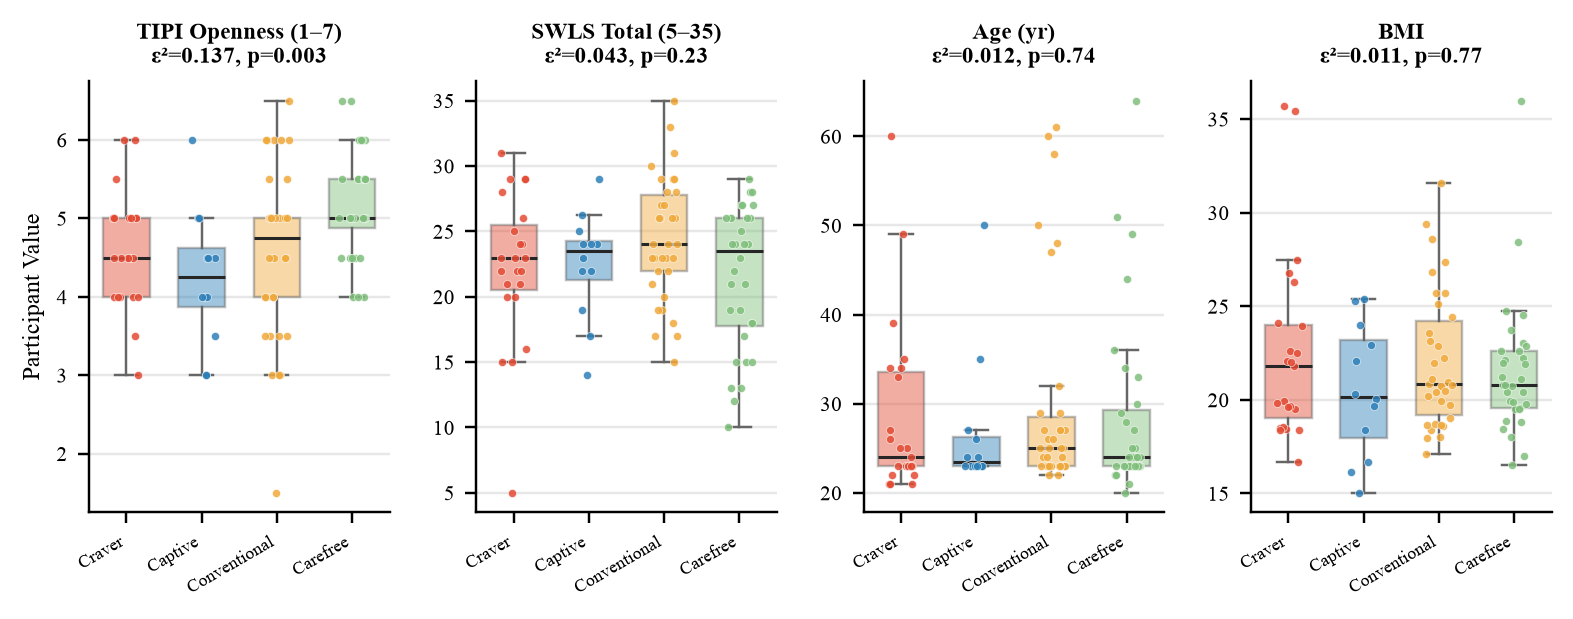

In [58]:
# ============================================================================
# --- Figure 02_B1 · Only Openness Separates The Archetypes ---
# Four onboarding dimensions (one significant + three null) as per-archetype
# box + jitter distributions; Kruskal-Wallis eps2/p annotated. Style matched
# to the ground-truth manuscript figure (Times New Roman, LB spines).
# ============================================================================
PANELS = [('Openness', 'TIPI Openness (1–7)'), ('SWLS Total', 'SWLS Total (5–35)'),
          ('Age', 'Age (yr)'), ('BMI', 'BMI')]
TS, PT, LS, TK, XT = 8.5, 7.5, 8, 7, 6            # suptitle / panel-title / ylabel / tick / xtick fonts
rng = np.random.default_rng(0)

fig, axes = plt.subplots(1, 4, figsize=(7.34, 3.02))
for ax, (v, ptitle) in zip(axes, PANELS):
    data = [D.loc[D['mnemonic'] == mn, v].dropna().values for mn in MN_ORDER]
    bp = ax.boxplot(data, positions=range(4), widths=0.62, patch_artist=True,
                    showfliers=False, medianprops=dict(color='0.15', lw=1.0),
                    whiskerprops=dict(color='0.4', lw=0.8), capprops=dict(color='0.4', lw=0.8),
                    boxprops=dict(edgecolor='0.4', lw=0.8))
    for patch, mn in zip(bp['boxes'], MN_ORDER):
        patch.set_facecolor(MPAL[mn]); patch.set_alpha(0.45)
    for i, (vals, mn) in enumerate(zip(data, MN_ORDER)):
        ax.scatter(i + rng.uniform(-0.18, 0.18, len(vals)), vals, s=7, color=MPAL[mn],
                   edgecolor='white', linewidth=0.2, alpha=0.85, zorder=3)
    N, e, p = kruskal_eps2(v)
    pstr = f'{p:.3f}' if p < 0.01 else f'{p:.2f}'
    ax.set_title(f'{ptitle}\n\u03b5\u00b2={e:.3f}, p={pstr}', fontsize=PT)
    ax.set_xticks(range(4)); ax.set_xticklabels(MN_ORDER, rotation=30, ha='right', fontsize=XT)
    ax.tick_params(axis='y', labelsize=TK)
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)
axes[0].set_ylabel('Participant Value', fontsize=LS)

fig.tight_layout()
os.makedirs(str(FIGDIR), exist_ok=True)
fig.savefig(f'{FIGDIR}/02_B1_openness_vs_null_dimensions.pdf')
plt.show()

## Summary

Starting from the public Cozie Singapore micro-surveys, this notebook reproduced the full analysis
behind the paper:

- **Cohort & features.** 9,520 valid responses from 106 participants; three empirical-Bayes-stabilized
  behavioral features retain **104 of 106** participants (Figures 3–4).
- **Four archetypes.** K=4 k-means yields the Craver, Captive, Conventional, and Carefree, with
  distinct standardized signatures (Figures 5–7) and the 22.1 / 11.5 / 33.7 / 32.7 % split.
- **Mechanistic scrutiny.** Two archetypes behave as thermal physiology predicts (cooling demand rises
  with heat and is relieved by A/C); two are decoupled from the physical environment (Figures 8–12).
- **Construct validity.** The archetypes show structure on independent behaviors but not on wearable
  physiology (Figures 13–14), and among stable onboarding traits only Openness separates them
  (Figure 15).
- **Robustness.** The partition is seed-stable (ARI ≈ 0.94) with soft boundary membership (subsample
  ARI ≈ 0.77; threshold ARI ≈ 0.47–0.65) — a behavioral continuum best read as four descriptive types.

Regenerated figures are written to `analysis/figures/` and participant-level tables to
`analysis/outputs/`; they reproduce the corresponding manuscript figures in `figures/`.